# Проект: Линейные модели в машинном обучении

## Описание проекта

Вы работаете в IT-компании, которая выполняет на заказ проекты по машинному обучению. К вам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».
Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих бурёнок!

Поэтому он просит нас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Вам нужно создать две прогнозные модели для отбора бурёнок в поголовье:
1. Первая будет прогнозировать возможный удой у коровы (целевой признак `Удой`);
2. Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак `Вкус молока`). С помощью модели нужно отобрать коров по двум критериям:
          
           - Средний удой за год — не менее 6000 килограммов,
           - Молоко должно быть вкусным.

**Что нужно сделать:**

- Построить модель линейной регрессии — для прогноза годового удоя (в кг).
- Построить модель логистической регрессии — для оценки вероятности вкусного молока (0/1).


**Особенности данных:**

- У фермера есть текущие данные по своим коровам (`ferma_main.csv`).
- Есть справочник по отцу каждой коровы (`ferma_dad.csv`).
- И есть данные на коров, которых он может купить (`cow_buy.csv`).


**Ключевые особенности:**

У коров из `cow_buy.csv` нет данных по корму, но известно, что его планируют улучшить. Поэтому при прогнозе нужно увеличить значения ЭКЕ, СПО и сырого протеина на 5%.
Прогнозировать надо по тем же признакам, что использовались при обучении модели на `ferma_main.csv`.


**Финальная задача:**
Предсказать удой и вкус молока для бурёнок из `cow_buy.csv`, и на основе результатов выбрать тех, кто подходит по обоим критериям.

## Цель исследования


1. Построить модель линейной регрессии для прогнозирования годового удоя коровы.
2. Построить модель логистической регрессии для предсказания вкуса молока.
3. Выявить факторы, влияющие на удой и вкус молока у коров.
4. Определить, какие бурёнки из предложенных подходят фермеру по обоим критериям.
5. Автоматизировать процесс принятия решения о покупке животных на основе данных.

**Ход исследования**

Моё исследование будет включать в себя несколько этапов, начиная с обзора данных и заканчивая построением моделей и выбором подходящих коров для покупки. Исходные данные находятся в трёх CSV-файлах: `/datasets/ferma_main.csv`, `/datasets/ferma_dad.csv`, и `/datasets/cow_buy.csv`.

Вначале я изучу структуру и качество данных: проверю названия столбцов, типы данных, пропуски и дубликаты. Проведу исследовательский и корреляционный анализ, чтобы выявить зависимости между признаками и целевыми переменными — удоем и вкусом молока.

После этого построю модели:

- базовую модель линейной регрессии;
- модель с устранением нелинейностей (например, переведу СПО в категорию, добавлю ЭКЕ²);
- модель с дополнительным фактором «Имя папы»;
и сравню их по метрикам точности (R², MSE, MAE, RMSE), выбрав лучшую.

Затем разработаю модель *логистической регрессии* для классификации вкуса молока, оценю её точность по метрикам `accuracy`, `precision`, `recall`, и рассмотрю матрицу ошибок. Особое внимание уделю анализу ложноотрицательных и ложноположительных прогнозов.

После этого применю обе лучшие модели к данным `cow_buy.csv`, заранее увеличив кормовые характеристики на 5% (согласно инструкции), чтобы учесть новый рацион.

Исследование будет проходить в следующих этапах:

1. Обзор данных — первичное изучение, соответствие описанию, проверка качества.
2. Предобработка — переименование столбцов, обработка пропусков, объединение таблиц.
3. Исследовательский анализ — визуализация, выявление выбросов и распределений.
4. Корреляционный анализ — изучение взаимосвязей между признаками и целевыми переменными.
5. Обучение моделей линейной регрессии — построение и сравнение трёх вариантов.
6. Обучение модели логистической регрессии — классификация вкуса, оценка ошибок.
7. Финальный отбор коров — прогноз по `cow_buy.csv`, выбор коров, соответствующих условиям.


## Шаг 1. Загрузка и изучение данных

In [ ]:
# Импорт библиотек
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, recall_score, precision_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

import warnings
warnings.filterwarnings('ignore')

IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

def save_plot(name: str, dpi: int = 300):
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Saved: {IMG_DIR / f'{name}.png'}")


🐮 ferma_main — данные фермера (ferma_main.csv)

In [2]:

# Возможные пути к файлу
paths = [
    'datasets/ferma_main.csv',
    '../data/ferma_main.csv',
    'ferma_main.csv'
]

filepath = None
for path in paths:
    if os.path.exists(path):
        filepath = path
        break

if filepath:
    ferma_main = pd.read_csv(filepath, sep=';')
    print(f"✅ Данные успешно загружены из: {filepath}")
    display(ferma_main.head())
else:
    print("⚠️ Файл ferma_main.csv не найден ни по одному из путей.")
    ferma_main = None


✅ Данные успешно загружены из: ../data/ferma_main.csv


,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


🧬 ferma_dad — справочник пап (ferma_dad.csv)

In [3]:
# Поиск пути к ferma_dad.csv
paths_dad = [
    'datasets/ferma_dad.csv',
    '../data/ferma_dad.csv',
    'ferma_dad.csv'
]

filepath_dad = None
for path in paths_dad:
    if os.path.exists(path):
        filepath_dad = path
        break

if filepath_dad:
    ferma_dad = pd.read_csv(filepath_dad, sep=';')
    print(f"✅ Данные ferma_dad успешно загружены из: {filepath_dad}")
    display(ferma_dad.head())
else:
    print("⚠️ Файл ferma_dad.csv не найден ни по одному из путей.")
    ferma_dad = None


✅ Данные ferma_dad успешно загружены из: ../data/ferma_dad.csv


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


🛒 cow_buy — коровы от «ЭкоФермы» (cow_buy.csv)

In [4]:
paths_buy = [
    'datasets/cow_buy.csv',
    '../data/cow_buy.csv',
    'cow_buy.csv'
]

filepath_buy = None
for path in paths_buy:
    if os.path.exists(path):
        filepath_buy = path
        break

if filepath_buy:
    cow_buy = pd.read_csv(filepath_buy, sep=';')
    print(f"✅ Данные cow_buy успешно загружены из: {filepath_buy}")
    display(cow_buy.head())
else:
    print("⚠️ Файл cow_buy.csv не найден ни по одному из путей.")
    cow_buy = None


✅ Данные cow_buy успешно загружены из: ../data/cow_buy.csv


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [5]:
# Быстрый просмотр первых строк всех таблиц
display(ferma_main.head(), ferma_dad.head(), cow_buy.head())


,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [6]:
# Первичный осмотр данных:
# - .info(): количество строк, пропуски, типы данных
# - .head(): первые 5 строк таблицы

for name, df in zip(['ferma_main', 'ferma_dad', 'cow_buy'], [ferma_main, ferma_dad, cow_buy]):
    print("="*60)
    print(f"\n{name.upper()} — INFO:")
    df.info()
    print(f"\n{name.upper()} — HEAD:")
    print(df.head())




FERMA_MAIN — INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11 

### Вывод на основе первичного анализа данных

Все три таблицы были успешно загружены с использованием `sep=';'`, что позволило сразу получить корректно структурированные датафреймы без необходимости ручного разбора строк.

#### 📌 `ferma_main` (634 строки, 12 колонок):
- Содержит подробные данные о коровах: удой, питательная ценность, порода, возраст и оценка вкуса молока.
- Три признака — числовые (`id`, `Удой, кг`, `Сырой протеин, г`), остальные представлены как строки (`object`). Часть из них нужно будет привести к числовому типу (например, `ЭКЕ`, `СПО`, `Жирность,%`, `Белок,%`).

#### 📌 `ferma_dad` (629 строк, 2 колонки):
- Таблица соответствия `id` и `Имя Папы`.
- Пропусков нет, структура корректна.

#### 📌 `cow_buy` (20 строк, 7 колонок):
- Содержит данные по потенциальным коровам для покупки.
- Все признаки — категориальные или числовые в текстовом формате (`object`).
- Требуется преобразовать признаки `Жирность,%` и `Текущий_уровень_белок,%` к числовому типу.

🔜 Следующим шагом будет предобработка данных: преобразование типов, создание новых признаков и подготовка к построению моделей.


## 🧼 Шаг 2. Предобработка данных

Перед анализом необходимо привести данные к корректному и единообразному виду. На этом этапе будут выполнены следующие действия:

1. **Проверка пропусков**  
   Будет проведена для всех трёх таблиц (`ferma_main`, `ferma_dad`, `cow_buy`) с использованием `.isna().sum()`.

2. **Проверка и устранение дубликатов**  
   Выполняется с помощью `df.duplicated().sum()` для каждой таблицы.

3. **Преобразование типов данных**  
   В таблицах `ferma_main` и `cow_buy` числовые признаки (`ЭКЕ`, `СПО`, `Жирность,%`, `Белок,%`, `Текущий_уровень_белок,%`) представлены в виде строк (`object`) из-за использования запятой как десятичного разделителя.  
   Эти признаки будут преобразованы: запятые заменены на точки, затем столбцы приведены к типу `float`.

4. **Приведение названий столбцов к единому стилю (`snake_case`) и перевод на английский язык**  
   Все названия колонок будут:
   - переведены на английский;
   - приведены к нижнему регистру;
   - очищены от пробелов, спецсимволов и заменены подчёркиваниями.

После этих шагов таблицы будут подготовлены для проведения исследовательского анализа данных (EDA).


In [7]:
# Проверка пропущенных значений для всех таблиц
for name, df in zip(['ferma_main', 'ferma_dad', 'cow_buy'], [ferma_main, ferma_dad, cow_buy]):
    print(f"\n{name.upper()} — MISSING VALUES:")
    print(df.isnull().sum())



FERMA_MAIN — MISSING VALUES:
id                                       0
Удой, кг                                 0
ЭКЕ (Энергетическая кормовая единица)    0
Сырой протеин, г                         0
СПО (Сахаро-протеиновое соотношение)     0
Порода                                   0
Тип пастбища                             0
порода папы_быка                         0
Жирность,%                               0
Белок,%                                  0
Вкус молока                              0
Возраст                                  0
dtype: int64

FERMA_DAD — MISSING VALUES:
id          0
Имя Папы    0
dtype: int64

COW_BUY — MISSING VALUES:
Порода                     0
Тип пастбища               0
порода папы_быка           0
Имя_папы                   0
Текущая_жирность,%         0
Текущий_уровень_белок,%    0
Возраст                    0
dtype: int64


#### 📋 Проверка пропущенных значений

Во всех трёх таблицах **пропусков не обнаружено**:

- `ferma_main` — все 634 строки содержат значения по всем признакам;
- `ferma_dad` — 629 строк, без пропусков в `id` и `Имя Папы`;
- `cow_buy` — все 20 строк полные, ни один признак не содержит `NaN`.

Таким образом, данные не требуют заполнения или удаления строк и могут быть сразу использованы для анализа и моделирования.


### Проверка на дубликаты

In [8]:
# Проверка на дубликаты
for name, df in zip(['ferma_main', 'ferma_dad', 'cow_buy'], [ferma_main, ferma_dad, cow_buy]):
    print(f"\n{name.upper()} — DUPLICATES:")
    print(df.duplicated().sum())


FERMA_MAIN — DUPLICATES:
5

FERMA_DAD — DUPLICATES:
0

COW_BUY — DUPLICATES:
4


In [9]:
# Посмотрим дубликаты в ferma_main
display(ferma_main[ferma_main.duplicated(keep=False)])

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
626,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
629,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
630,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
631,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
632,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет
633,627,5970,"14,4",1837,"0,88",РефлешнСоверинг,Холмистое,Соверин,"3,64","3,075",не вкусно,более_2_лет


In [10]:
# Уникальные id среди дубликатов
print("\nDUPLICATE IDS in ferma_main:")
print(ferma_main[ferma_main.duplicated(keep=False)]['id'].value_counts())



DUPLICATE IDS in ferma_main:
id
627    6
Name: count, dtype: int64


In [11]:
# Удаляем дубликаты
ferma_main = ferma_main.drop_duplicates()

# Проверяем, что дубликаты удалены
print(f"\nFERMA_MAIN — DUPLICATES AFTER REMOVAL: {ferma_main.duplicated().sum()}")


FERMA_MAIN — DUPLICATES AFTER REMOVAL: 0


In [12]:
# Посмотрим дубликаты в cow_buy
display(cow_buy[cow_buy.duplicated(keep=False)])

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
14,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [13]:
# Уникальные строки среди дубликатов
print("\nDUPLICATE ROWS in cow_buy:")
print(cow_buy[cow_buy.duplicated(keep=False)].value_counts())


DUPLICATE ROWS in cow_buy:
Порода           Тип пастбища  порода папы_быка  Имя_папы  Текущая_жирность,%  Текущий_уровень_белок,%  Возраст    
РефлешнСоверинг  равнинное     Соверин           Барин     3,59                3,074                    более_2_лет    3
Вис Бик Айдиал   холмистое     Айдиал            Геркулес  3,58                3,076                    более_2_лет    2
РефлешнСоверинг  равнинное     Айдиал            Буйный    3,64                3,074                    более_2_лет    2
Name: count, dtype: int64


In [14]:
# Удаляем дубликаты
cow_buy = cow_buy.drop_duplicates()

# Проверяем, что дубликаты удалены
print(f"\nCOW_BUY — DUPLICATES AFTER REMOVAL: {cow_buy.duplicated().sum()}")


COW_BUY — DUPLICATES AFTER REMOVAL: 0


#### 🔧 Приведение типов и форматирование

Несколько признаков с числовыми значениями (например, `Жирность,%`, `Белок,%`, `ЭКЕ`, `СПО`) были загружены как строки (`object`) из-за использования запятой в качестве десятичного разделителя.

На этом этапе будут выполнены следующие действия:

- Замена запятых на точки в числовых столбцах;
- Преобразование этих признаков в числовой тип (`float`);
- Приведение названий столбцов к единому стилю `snake_case` (нижний регистр, без пробелов и спецсимволов) для удобства в дальнейшем анализе и построении моделей.


In [15]:
# Копируем датафреймы
ferma_main_clean = ferma_main.copy()
cow_buy_clean = cow_buy.copy()

# Приведение типов в ferma_main
for col in ['ЭКЕ (Энергетическая кормовая единица)', 'СПО (Сахаро-протеиновое соотношение)', 'Жирность,%', 'Белок,%']:
    ferma_main_clean[col] = ferma_main_clean[col].str.replace(',', '.', regex=False).astype(float)

# Приведение типов в cow_buy
for col in ['Текущая_жирность,%', 'Текущий_уровень_белок,%']:
    cow_buy_clean[col] = cow_buy_clean[col].str.replace(',', '.', regex=False).astype(float)

# Проверка результата
print(ferma_main_clean.dtypes)
print(cow_buy_clean.dtypes)


id                                         int64
Удой, кг                                   int64
ЭКЕ (Энергетическая кормовая единица)    float64
Сырой протеин, г                           int64
СПО (Сахаро-протеиновое соотношение)     float64
Порода                                    object
Тип пастбища                              object
порода папы_быка                          object
Жирность,%                               float64
Белок,%                                  float64
Вкус молока                               object
Возраст                                   object
dtype: object
Порода                      object
Тип пастбища                object
порода папы_быка            object
Имя_папы                    object
Текущая_жирность,%         float64
Текущий_уровень_белок,%    float64
Возраст                     object
dtype: object


In [16]:
# Переименование колонок в ferma_main_clean
ferma_main_clean = ferma_main_clean.rename(columns={
    'id': 'id',
    'Удой, кг': 'milk_yield',
    'ЭКЕ (Энергетическая кормовая единица)': 'eke_feeding_unit',
    'Сырой протеин, г': 'crude_protein_g',
    'СПО (Сахаро-протеиновое соотношение)': 'spo_ratio',
    'Порода': 'breed',
    'Тип пастбища': 'pasture_type',
    'порода папы_быка': 'father_breed',
    'Жирность,%': 'fat_pct',
    'Белок,%': 'protein_pct',
    'Вкус молока': 'taste',
    'Возраст': 'age_group'
})

# Переименование колонок в cow_buy_clean
cow_buy_clean = cow_buy_clean.rename(columns={
    'Порода': 'breed',
    'Тип пастбища': 'pasture_type',
    'порода папы_быка': 'father_breed',
    'Имя_папы': 'father_name',
    'Текущая_жирность,%': 'current_fat_pct',
    'Текущий_уровень_белок,%': 'current_protein_pct',
    'Возраст': 'age_group'
})

# Переименование колонок в ferma_dad
ferma_dad = ferma_dad.rename(columns={
    'id': 'id',
    'Имя Папы': 'father_name'
})



In [17]:
# Проверим результат преобразований в ferma_main_clean
print("FERMA_MAIN_CLEAN — STRUCTURE:")
print(ferma_main_clean.info())
print("\nFERMA_MAIN_CLEAN — DESCRIPTIVE STATS:")
display(ferma_main_clean.describe())

# Проверим результат преобразований в cow_buy_clean
print("\nCOW_BUY_CLEAN — STRUCTURE:")
print(cow_buy_clean.info())
print("\nCOW_BUY_CLEAN — DESCRIPTIVE STATS:")
display(cow_buy_clean.describe())

# Проверим результат преобразований в ferma_dad
print("\nFERMA_DAD — STRUCTURE:")
print(ferma_dad.info())
print("\nFERMA_DAD — UNIQUE VALUES:")
display(ferma_dad['father_name'].value_counts())


FERMA_MAIN_CLEAN — STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                629 non-null    int64  
 1   milk_yield        629 non-null    int64  
 2   eke_feeding_unit  629 non-null    float64
 3   crude_protein_g   629 non-null    int64  
 4   spo_ratio         629 non-null    float64
 5   breed             629 non-null    object 
 6   pasture_type      629 non-null    object 
 7   father_breed      629 non-null    object 
 8   fat_pct           629 non-null    float64
 9   protein_pct       629 non-null    float64
 10  taste             629 non-null    object 
 11  age_group         629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.9+ KB
None

FERMA_MAIN_CLEAN — DESCRIPTIVE STATS:


,id,milk_yield,eke_feeding_unit,crude_protein_g,spo_ratio,fat_pct,protein_pct
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000



COW_BUY_CLEAN — STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 0 to 18
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   breed                16 non-null     object 
 1   pasture_type         16 non-null     object 
 2   father_breed         16 non-null     object 
 3   father_name          16 non-null     object 
 4   current_fat_pct      16 non-null     float64
 5   current_protein_pct  16 non-null     float64
 6   age_group            16 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.0+ KB
None

COW_BUY_CLEAN — DESCRIPTIVE STATS:


,current_fat_pct,current_protein_pct
count,16.000000,16.000000
mean,3.571875,3.068250
std,0.141620,0.011264
min,3.340000,3.046000
25%,3.415000,3.059500
50%,3.585000,3.073500
75%,3.692500,3.076750
max,3.770000,3.081000



FERMA_DAD — STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           629 non-null    int64 
 1   father_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None

FERMA_DAD — UNIQUE VALUES:


father_name
Барин       240
Буйный      215
Соловчик    110
Геркулес     64
Name: count, dtype: int64

#### 🏷 Переименование колонок

Для удобства дальнейшей работы все названия колонок были приведены к единому стилю:
- переведены на английский язык;
- приведены к `snake_case` (нижний регистр, без пробелов и спецсимволов).



#### 📊 Проверка преобразований

С помощью `.info()` и `.describe()` была проведена проверка итоговой структуры и содержимого таблиц.  
Все числовые признаки успешно приведены к типу `float`, а названия колонок — стандартизированы.  



#### 🔎 Поиск неявных дубликатов в категориальных признаках

Чтобы выявить возможные опечатки и непоследовательности в данных проверим на неявные дубликаты. Подобные расхождения могут повлиять на группировки, визуализации и качество модели.

In [18]:
# Проверка на неявные дубликаты в категориальных признаках
categorical_columns = [
    'breed', 'pasture_type', 'father_breed', 'taste', 'age_group'
]

# Собираем уникальные значения по каждой колонке
unique_values = {
    col: sorted(ferma_main_clean[col].unique()) for col in categorical_columns
}

# Формируем таблицу для визуального анализа
unique_values_df = pd.DataFrame(dict([
    (col, pd.Series(values)) for col, values in unique_values.items()
]))

# Отображаем результат
display(unique_values_df)


,breed,pasture_type,father_breed,taste,age_group
0,Вис Бик Айдиал,Равнинное,Айдиал,вкусно,более_2_лет
1,РефлешнСоверинг,Равнинные,Айдиалл,не вкусно,менее_2_лет
2,NaN,Холмистое,Соверин,NaN,NaN


In [19]:
# Исправляем ошибки и опечатки в категориальных признаках

# Исправляем тип пастбища
ferma_main_clean['pasture_type'] = ferma_main_clean['pasture_type'].replace({
    'Равнинные': 'Равнинное'
})

# Исправляем породу отца
ferma_main_clean['father_breed'] = ferma_main_clean['father_breed'].replace({
    'Айдиалл': 'Айдиал'
})

# 


In [20]:
# Проверяем уникальные значения после исправлений
for col in ['pasture_type', 'father_breed']:
    print(f"\nUnique values in {col}:")
    print(sorted(ferma_main_clean[col].unique()))



Unique values in pasture_type:
['Равнинное', 'Холмистое']

Unique values in father_breed:
['Айдиал', 'Соверин']


In [21]:
# Проверка cow_buy_clean на неявные дубликаты (полные совпадения по всем признакам)
duplicate_rows = (
    cow_buy_clean
    .value_counts()
    .reset_index(name='count')
    .query('count > 1')
)

display(duplicate_rows)


,breed,pasture_type,father_breed,father_name,current_fat_pct,current_protein_pct,age_group,count


In [22]:
# Проверим уникальные значения всех трех датасетов 
# Категориальные признаки для проверки
columns_to_check = ['breed', 'pasture_type', 'father_breed', 'age_group']

print("FERMA_MAIN_CLEAN — уникальные значения:")
for col in columns_to_check:
    print(f"\n{col}:")
    print(sorted(ferma_main_clean[col].dropna().unique()))

print("\n\nCOW_BUY_CLEAN — уникальные значения:")
for col in columns_to_check:
    print(f"\n{col}:")
    print(sorted(cow_buy_clean[col].dropna().unique()))

print("\n\nFERMA_DAD — уникальные значения:")
print(sorted(ferma_dad['father_name'].dropna().unique()))


FERMA_MAIN_CLEAN — уникальные значения:

breed:
['Вис Бик Айдиал', 'РефлешнСоверинг']

pasture_type:
['Равнинное', 'Холмистое']

father_breed:
['Айдиал', 'Соверин']

age_group:
['более_2_лет', 'менее_2_лет']


COW_BUY_CLEAN — уникальные значения:

breed:
['Вис Бик Айдиал', 'РефлешнСоверинг']

pasture_type:
['равнинное', 'холмистое']

father_breed:
['Айдиал', 'Соверин']

age_group:
['более_2_лет', 'менее_2_лет']


FERMA_DAD — уникальные значения:
['Барин', 'Буйный', 'Геркулес', 'Соловчик']


In [23]:
# Категориальные колонки, которые нужно привести к нижнему регистру
columns_to_lower = ['breed', 'pasture_type', 'father_breed', 'age_group']

# Приводим к нижнему регистру в ferma_main_clean
for col in columns_to_lower:
    ferma_main_clean[col] = ferma_main_clean[col].str.lower()

# Приводим к нижнему регистру в cow_buy_clean
for col in columns_to_lower:
    cow_buy_clean[col] = cow_buy_clean[col].str.lower()

# Проверяем результат: выводим уникальные значения по каждой колонке
print("FERMA_MAIN_CLEAN — уникальные значения:")
for col in columns_to_lower:
    print(f"\n{col}:")
    print(sorted(ferma_main_clean[col].dropna().unique()))

print("\n\nCOW_BUY_CLEAN — уникальные значения:")
for col in columns_to_lower:
    print(f"\n{col}:")
    print(sorted(cow_buy_clean[col].dropna().unique()))



FERMA_MAIN_CLEAN — уникальные значения:

breed:
['вис бик айдиал', 'рефлешнсоверинг']

pasture_type:
['равнинное', 'холмистое']

father_breed:
['айдиал', 'соверин']

age_group:
['более_2_лет', 'менее_2_лет']


COW_BUY_CLEAN — уникальные значения:

breed:
['вис бик айдиал', 'рефлешнсоверинг']

pasture_type:
['равнинное', 'холмистое']

father_breed:
['айдиал', 'соверин']

age_group:
['более_2_лет', 'менее_2_лет']


### ✅ Вывод по этапу предобработки данных

На этапе предобработки были выполнены все необходимые шаги для подготовки данных к анализу и моделированию:

1. **Загрузка данных**  
   Все таблицы (`ferma_main`, `ferma_dad`, `cow_buy`) были успешно загружены с указанием `sep=';'`, без потери данных или ошибок кодировки.

2. **Проверка пропусков и дубликатов**  
   - Пропущенные значения отсутствуют во всех таблицах.  
   - Были выявлены и удалены как полные, так и неявные дубликаты строк (по смыслу, а не только по `id`).

3. **Преобразование типов**  
   - Числовые признаки, содержащие запятые как десятичный разделитель, были преобразованы в `float`;  
   - Типы данных приведены к корректным: числовые — к числовым, категориальные — к `object`.

4. **Переименование колонок**  
   - Все названия колонок переведены на английский язык и приведены к единому стилю `snake_case`.


5. **Проверка категориальных признаков**  
   - Обнаружены и исправлены опечатки и несоответствия в названиях категорий (`Айдиалл` → `Айдиал`, `Равнинные` → `Равнинное`), которые могли привести к логическим ошибкам при анализе.

6. **Очистка категориальных признаков**
   - Все категориальные признаки (`breed`, `pasture_type`, `father_breed`, `age_group`) были успешно приведены к нижнему регистру. Проверка уникальных значений показала, что теперь написание унифицировано, а неявные дубликаты отсутствуют.

    - 🔒 Переменная `father_name` не изменялась, так как содержит имена собственные, которые сохраняются в оригинальном виде.

🔎 В результате всех шагов таблицы готовы к проведению исследовательского анализа (EDA) и построению моделей.


## 📊 Исследовательский анализ данных (EDA)

### Анализ распределений количественных признаков

Сначала визуализируем распределения всех количественных признаков в `ferma_main_clean`, чтобы:

- увидеть выбросы и аномалии;
- оценить форму распределения (нормальное, смещённое, мультимодальное);
- подумать, нужно ли лог-преобразование или стандартизация.

Saved: ../images/numeric_feature_histograms.png


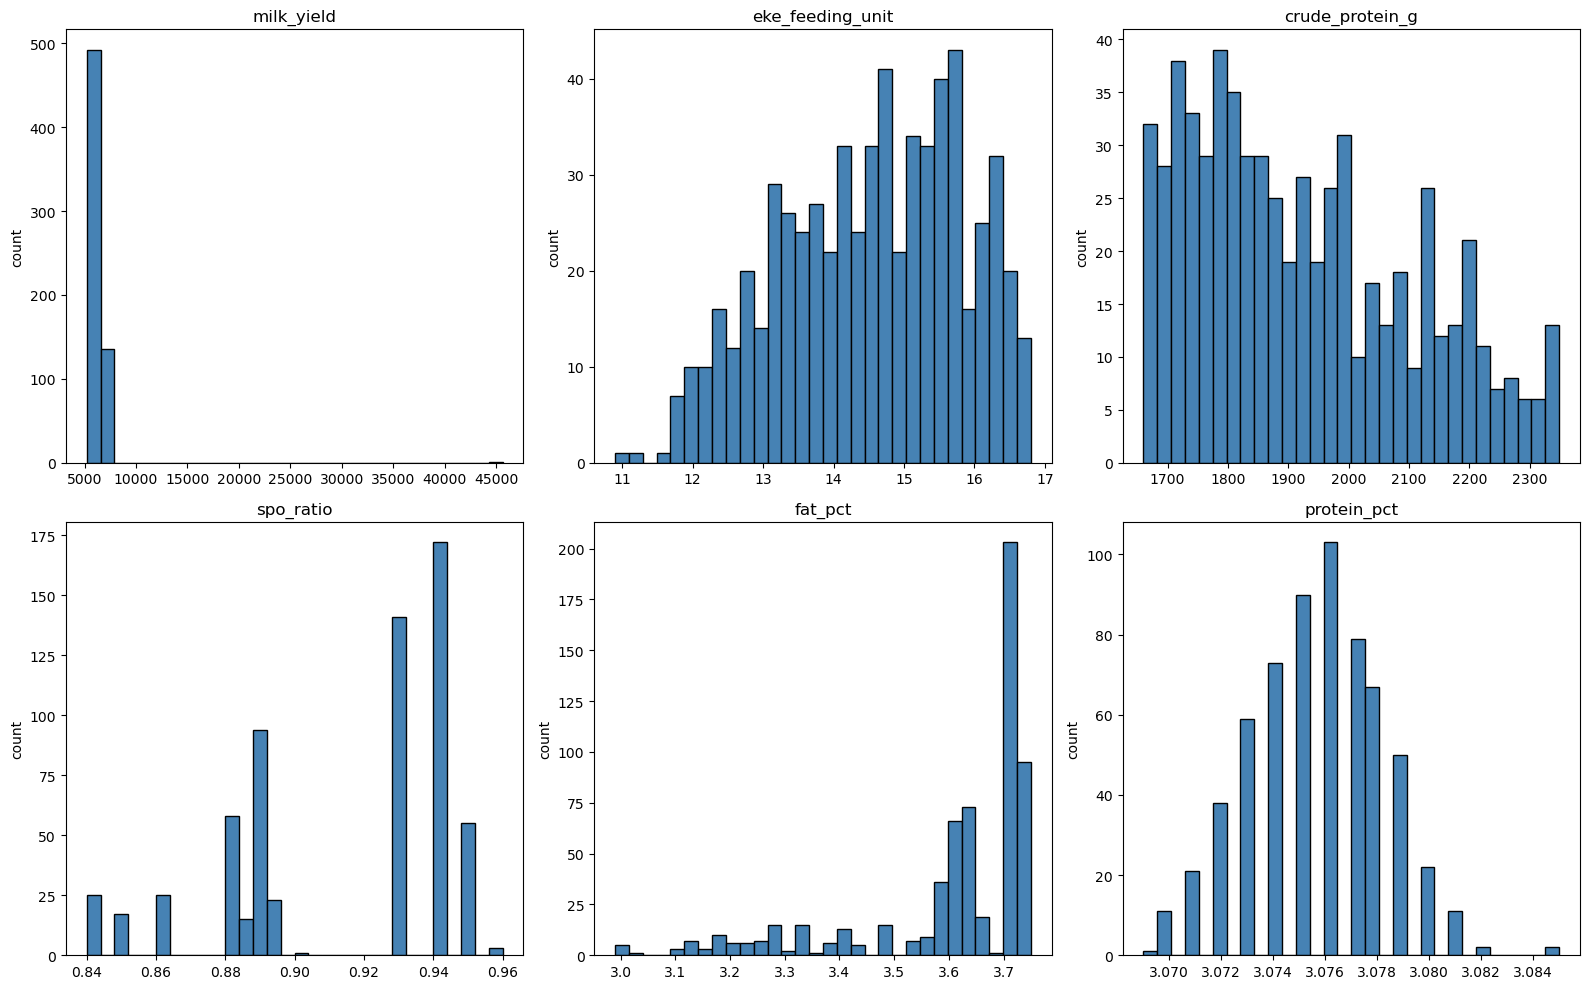

In [24]:
# Гистограммы для всех количественных признаков
num_cols = [
    'milk_yield', 'eke_feeding_unit', 'crude_protein_g',
    'spo_ratio', 'fat_pct', 'protein_pct'
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(ferma_main_clean[col], bins=30, color='steelblue', edgecolor='black')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('count')
plt.tight_layout()
save_plot("numeric_feature_histograms")
plt.show()


#### **Гистограммы**

1. `milk_yield` (удой)
- Очень сильный выброс около 45 000, тогда как основная масса лежит между 5000 и 7000.
2. `eke_feeding_unit` и `crude_protein_g`
- Распределения похожи на нормальные, но с небольшим смещением и “хвостами”.
3. `spo_ratio`
- Странная гистограмма: неравномерные пики.
4. `fat_pct`
- Явно сильно смещено вправо — большинство значений в узком диапазоне 3.6–3.7
5. `protein_pct`
- Почти нормальное, но очень узкое распределение
- Очень высокая точность, почти константа?

Saved: ../images/milk_yield_histogram_clipped_99pct.png


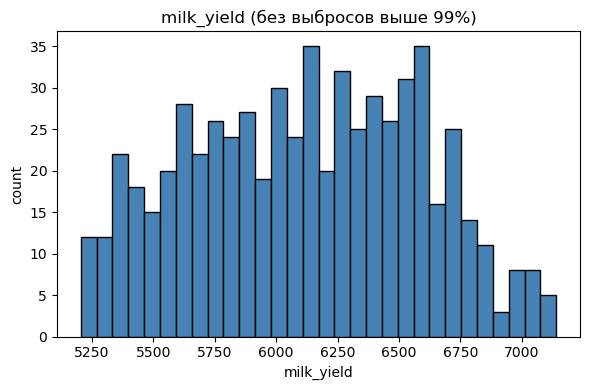

Saved: ../images/eke_feeding_unit_histogram_clipped_99pct.png


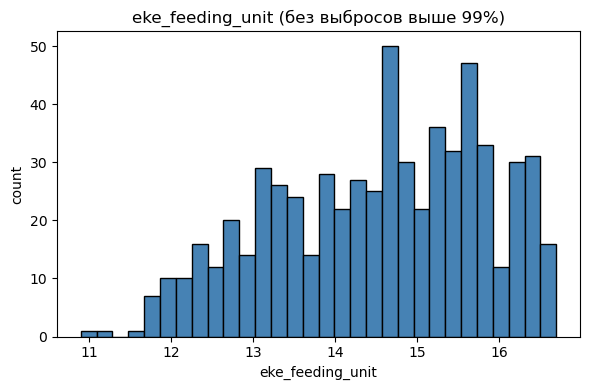

Saved: ../images/crude_protein_g_histogram_clipped_99pct.png


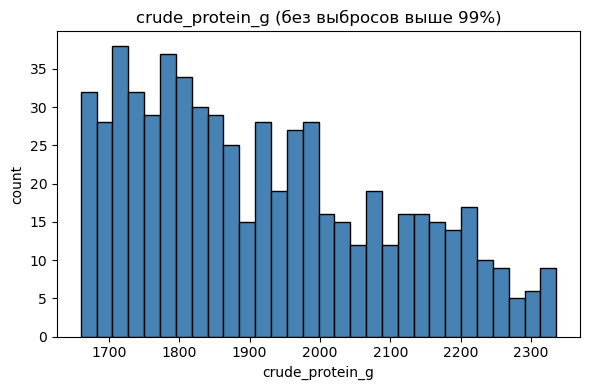

Saved: ../images/spo_ratio_histogram_clipped_99pct.png


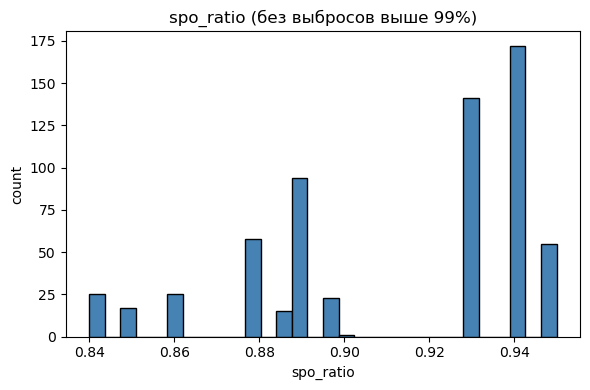

Saved: ../images/fat_pct_histogram_clipped_99pct.png


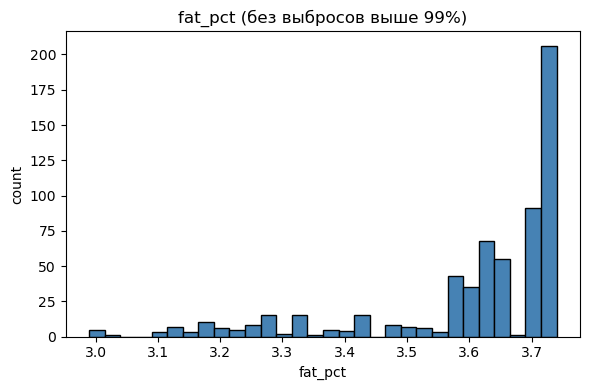

Saved: ../images/protein_pct_histogram_clipped_99pct.png


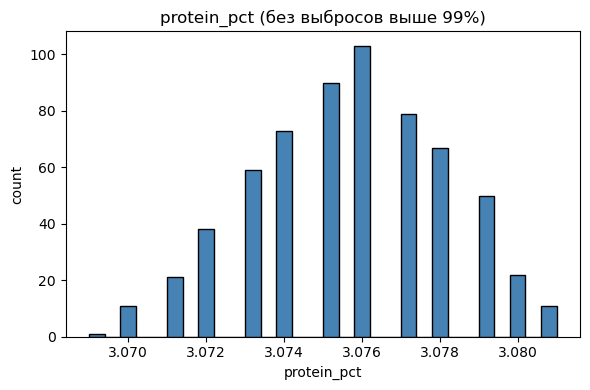

In [25]:

# Список числовых колонок
num_cols = [
    'milk_yield', 'eke_feeding_unit', 'crude_protein_g',
    'spo_ratio', 'fat_pct', 'protein_pct'
]

# Определим, на каком процентиле обрезать выбросы
clip_pct = 0.99  # верхняя отсечка на 99-м процентиле

# Построим гистограммы без выбросов
for col in num_cols:
    threshold = ferma_main_clean[col].quantile(clip_pct)
    clipped_data = ferma_main_clean[ferma_main_clean[col] <= threshold][col]
    
    plt.figure(figsize=(6, 4))
    plt.hist(clipped_data, bins=30, color='steelblue', edgecolor='black')
    plt.title(f'{col} (без выбросов выше {clip_pct*100:.0f}%)')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.tight_layout()
    save_plot(f"{col}_histogram_clipped_99pct")
    plt.show()


#### **Гистограммы (Распределения количественных признаков (без выбросов))**

Для наглядности распределения всех числовых признаков были визуализированы с отсечкой 1% самых высоких значений. Это позволило убрать аномальные выбросы (в частности, в `milk_yield`) и более точно оценить форму распределений:

- `milk_yield`, `eke_feeding_unit`, `crude_protein_g` — близки к нормальным или умеренно смещены;
- `spo_ratio` — имеет ступенчатую структуру, вероятно, из-за округления;
- `fat_pct` — с выраженным пиком у верхней границы (ближе к 3.7%);
- `protein_pct` — почти константа, варьируется в очень узком диапазоне.

Распределения не требуют обязательного лог-преобразования, но могут быть нормализованы при необходимости на этапе построения модели.


#### **Boxplot для количественных признаков**

Saved: ../images/milk_yield_boxplot.png


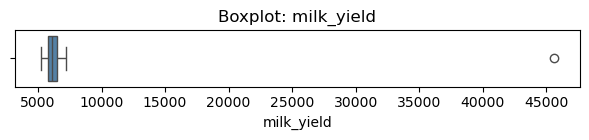

Saved: ../images/eke_feeding_unit_boxplot.png


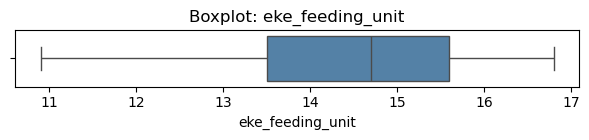

Saved: ../images/crude_protein_g_boxplot.png


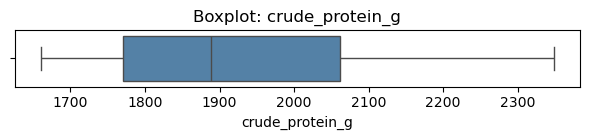

Saved: ../images/spo_ratio_boxplot.png


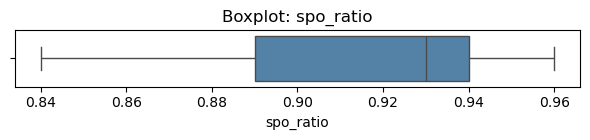

Saved: ../images/fat_pct_boxplot.png


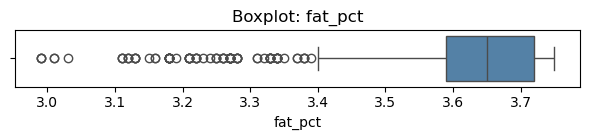

Saved: ../images/protein_pct_boxplot.png


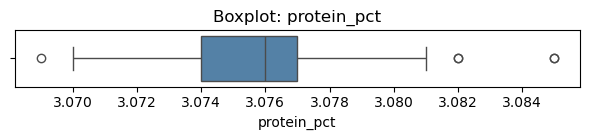

In [26]:

# Список числовых признаков
num_cols = [
    'milk_yield', 'eke_feeding_unit', 'crude_protein_g',
    'spo_ratio', 'fat_pct', 'protein_pct'
]

# Построим boxplot для каждого признака
for col in num_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=ferma_main_clean[col], color='steelblue')
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    save_plot(f"{col}_boxplot") 
    plt.show()


#### **Выводы из boxplot'ов:**


1. `milk_yield`:
- Видно одиночный экстремальный выброс (~45 000 кг), остальной диапазон — 5200–7000 кг.
- Данные очень плотные, распределение здоровое после отсечения.
2. `eke_feeding_unit` и `crude_protein_g`:
- Распределены хорошо, почти без выбросов.
- Можно использовать напрямую.
3. `spo_ratio`:
- Нет экстремальных выбросов.
- Распределение плотное, хотя гистограмма показала ступенчатость.
4. `fat_pct`:
- Много выбросов ниже 3.4%, основной пик — около 3.7%.
- Возможно, стоит выделить группы по жирности.
5. `protein_pct`:
- Очень узкий интервал, но выбросы на границах всё же есть.
- Почти константа — вряд ли сыграет роль в модели.


### 🎯 Выделение целевого признака `taste`

На данном этапе анализа мы выделим целевой признак для будущего моделирования.  
В рамках задачи — помочь фермеру отобрать коров с **высокой продуктивностью и вкусным молоком** — логично рассматривать признак `taste` как ключевой, так как он отражает **качество конечного продукта** с точки зрения потребителя.

Признак `taste` имеет два значения:
- `'вкусно'` — 1
- `'не вкусно'` — 0

Он будет использоваться в задачах бинарной классификации.




In [27]:
print(ferma_main_clean['taste'].unique())


['вкусно' 'не вкусно']


In [28]:
# Приведём значения к нижнему регистру и удалим лишние пробелы
ferma_main_clean['taste'] = ferma_main_clean['taste'].str.strip().str.lower()

# Преобразуем в бинарный формат: 1 = вкусно, 0 = не вкусно
ferma_main_clean['taste'] = ferma_main_clean['taste'].map({
    'вкусно': 1,
    'не вкусно': 0
})


In [29]:
print(ferma_main_clean['taste'].value_counts())


taste
1    371
0    258
Name: count, dtype: int64


#### **В рамках определения целевого признака:**

- провели очистку значений от лишних пробелов и привели их к единому регистру;
- закодировали признак в бинарном формате.

Распределение по классам:
- вкусное молоко — **371** наблюдение;
- невкусное молоко — **258** наблюдений.

Распределение умеренно сбалансировано, и обе группы представлены достаточно для анализа.

#### **Визуализация распределениий целевых признаков**

##### **Визуализация распределения целевого признака `taste`**

Saved: ../images/taste_target_distribution.png


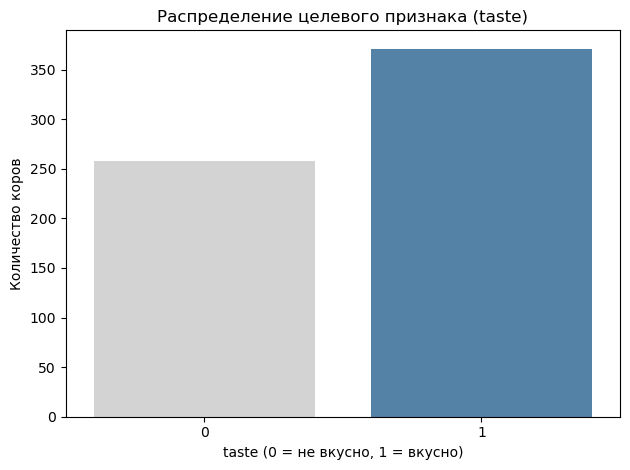

In [30]:
sns.countplot(x='taste', data=ferma_main_clean, palette=['lightgrey', 'steelblue'])
plt.title('Распределение целевого признака (taste)')
plt.xlabel('taste (0 = не вкусно, 1 = вкусно)')
plt.ylabel('Количество коров')
plt.tight_layout()
save_plot("taste_target_distribution")
plt.show()


Saved: ../images/milk_yield_boxplot_by_taste.png


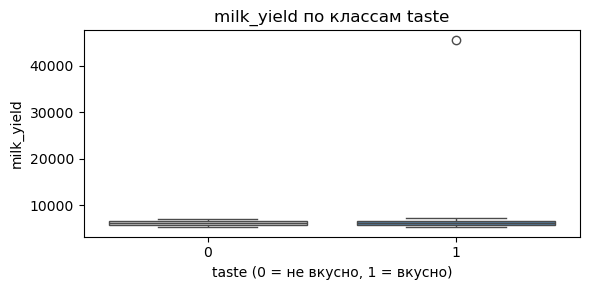

Saved: ../images/eke_feeding_unit_boxplot_by_taste.png


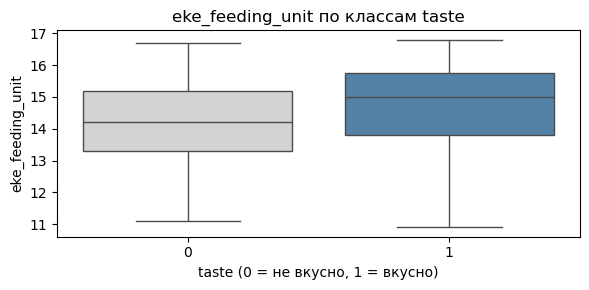

Saved: ../images/crude_protein_g_boxplot_by_taste.png


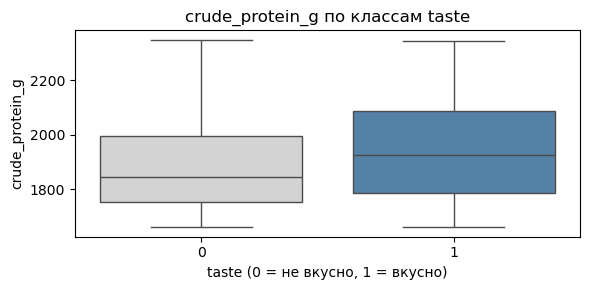

Saved: ../images/spo_ratio_boxplot_by_taste.png


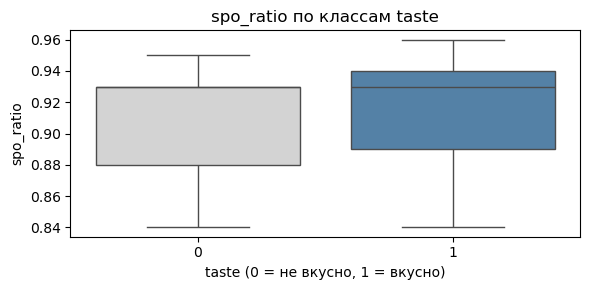

Saved: ../images/fat_pct_boxplot_by_taste.png


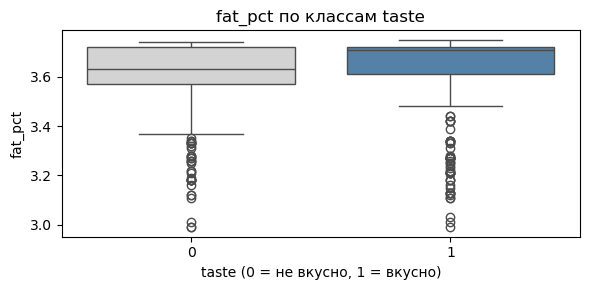

Saved: ../images/protein_pct_boxplot_by_taste.png


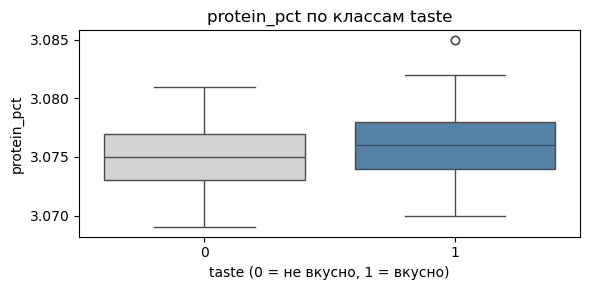

In [31]:
# Список количественных признаков
num_cols = [
    'milk_yield', 'eke_feeding_unit', 'crude_protein_g',
    'spo_ratio', 'fat_pct', 'protein_pct'
]

# Строим boxplot'ы с разбивкой по вкусу молока
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='taste', y=col, data=ferma_main_clean, palette=['lightgrey', 'steelblue'])
    plt.title(f'{col} по классам taste')
    plt.xlabel('taste (0 = не вкусно, 1 = вкусно)')
    plt.ylabel(col)
    plt.tight_layout()
    save_plot(f"{col}_boxplot_by_taste") 
    plt.show()


##### **Визуализация распределения целевого признака `milk_yield`**

Saved: ../images/milk_yield_distribution_and_boxplot.png


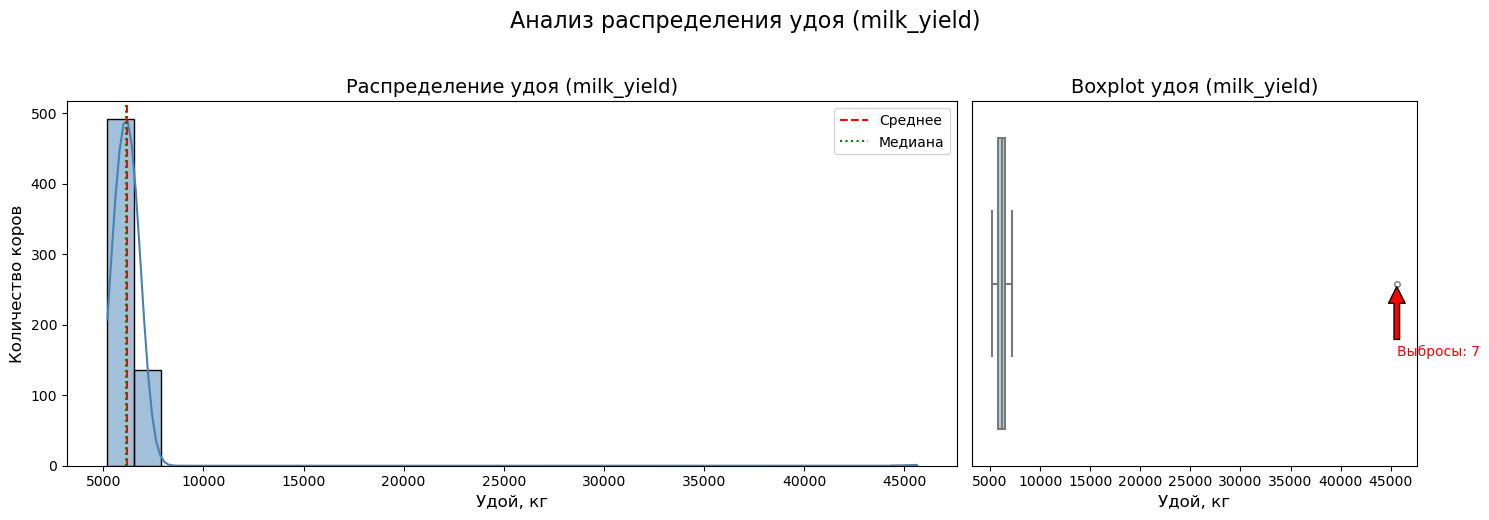

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# Гистограмма с KDE и аннотациями
sns.histplot(
    ferma_main_clean['milk_yield'],
    bins=30, kde=True, ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Распределение удоя (milk_yield)', fontsize=14)
axes[0].set_xlabel('Удой, кг', fontsize=12)
axes[0].set_ylabel('Количество коров', fontsize=12)
axes[0].axvline(ferma_main_clean['milk_yield'].mean(), color='red', linestyle='--', label='Среднее')
axes[0].axvline(ferma_main_clean['milk_yield'].median(), color='green', linestyle=':', label='Медиана')
axes[0].legend()

# Boxplot с аннотацией выбросов
sns.boxplot(
    x=ferma_main_clean['milk_yield'],
    ax=axes[1], color='lightblue', fliersize=4, linewidth=1.5
)
axes[1].set_title('Boxplot удоя (milk_yield)', fontsize=14)
axes[1].set_xlabel('Удой, кг', fontsize=12)
axes[1].set_yticks([])

# Аннотация выбросов
outliers = ferma_main_clean[ferma_main_clean['milk_yield'] > ferma_main_clean['milk_yield'].quantile(0.99)]
if not outliers.empty:
    axes[1].annotate(
        f'Выбросы: {len(outliers)}',
        xy=(outliers['milk_yield'].values[0], 0),
        xytext=(outliers['milk_yield'].values[0], 0.2),
        arrowprops=dict(facecolor='red', shrink=0.05),
        fontsize=10, color='red'
    )

plt.suptitle('Анализ распределения удоя (milk_yield)', fontsize=16, y=1.03)
plt.tight_layout()
save_plot("milk_yield_distribution_and_boxplot")
plt.show()


##### **Анализ распределения целевого признака milk_yield**

На графиках видно, что:

- распределение асимметрично — с длинным правым хвостом;
- медиана ниже среднего, что указывает на наличие выбросов;
- выявлено 7 выбросов выше 99-го процентиля (в районе 45000 кг), тогда как основная масса данных лежит между 5000 и 7500 кг.

Эти выбросы стоит учесть при моделировании — в частности, попробовать обучить модель и с ними, и без них, чтобы оценить влияние на качество прогноза.


#### 📊 **Сравнение количественных признаков по классам `taste`**

Boxplot-графики показали следующие закономерности:

- **`milk_yield`** и **`crude_protein_g`** выше у коров с вкусным молоком;
- **`eke_feeding_unit`** также показывает сдвиг вправо у вкусных — возможно, они потребляют больше энергии;
- **`spo_ratio`** и **`fat_pct`** слегка выше у вкусных, но различия несущественные;
- **`protein_pct`** варьируется минимально — вероятно, малополезен для модели.

В целом, можно ожидать, что `milk_yield`, `eke_feeding_unit` и `crude_protein_g` будут информативными признаками при построении модели классификации.


#### **Анализ категориальных признаков с разбивкой по `taste`**

🔍 Что будем делать:

1. Проверим уникальные значения и частоты:
- `breed`
- `pasture_type`
- `father_breed`
- `age_group`
- (опционально) `father_name` (если решим объединить `ferma_dad`)
2. Построим barplot’ы: частота категорий в каждом классе (`taste=0` и `taste=1`)



BREED — value_counts():
breed
вис бик айдиал     373
рефлешнсоверинг    256
Name: count, dtype: int64


Saved: ../images/breed_countplot_by_taste.png


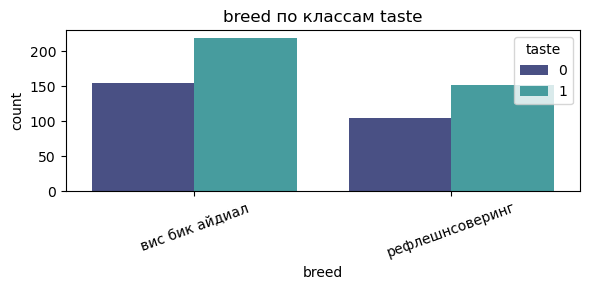


PASTURE_TYPE — value_counts():
pasture_type
холмистое    351
равнинное    278
Name: count, dtype: int64
Saved: ../images/pasture_type_countplot_by_taste.png


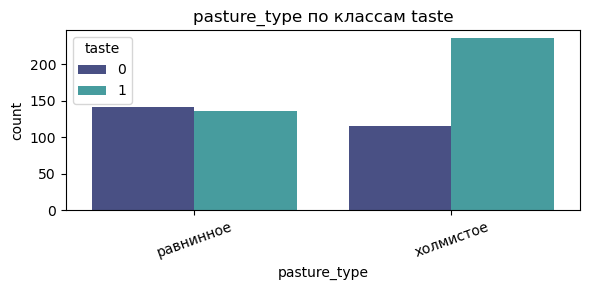


FATHER_BREED — value_counts():
father_breed
айдиал     318
соверин    311
Name: count, dtype: int64
Saved: ../images/father_breed_countplot_by_taste.png


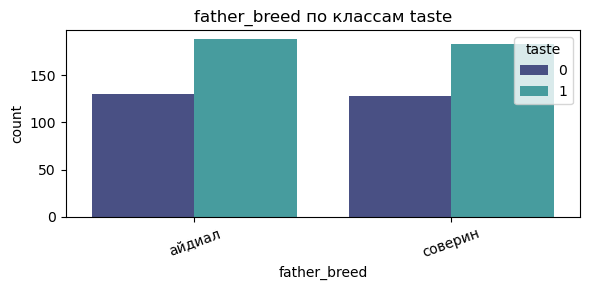


AGE_GROUP — value_counts():
age_group
более_2_лет    519
менее_2_лет    110
Name: count, dtype: int64
Saved: ../images/age_group_countplot_by_taste.png


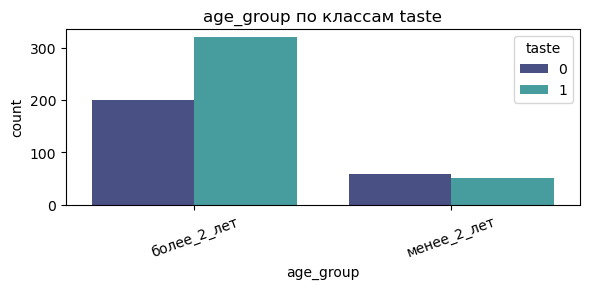

In [33]:

# Категориальные признаки
cat_cols = ['breed', 'pasture_type', 'father_breed', 'age_group']

for col in cat_cols:
    print(f"\n{col.upper()} — value_counts():")
    print(ferma_main_clean[col].value_counts())

    # График
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, hue='taste', data=ferma_main_clean, palette= 'mako')
    plt.title(f'{col} по классам taste')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=20)
    plt.tight_layout()
    save_plot(f"{col}_countplot_by_taste")
    plt.show()


#### 📊 **Анализ категориальных признаков**

Построены barplot-графики по всем категориальным признакам с разбивкой по `taste`.

Выводы:
- **`breed`**: порода `вис бик айдиал` даёт больше вкусного молока, чем `рефлешнсоверинг`;
- **`pasture_type`**: холмистые пастбища ассоциированы с более вкусным молоком;
- **`father_breed`**: нет выраженной связи с вкусом молока;
- **`age_group`**: вкусное молоко чаще встречается у коров старше 2 лет, молодые коровы представлены слабо.

Таким образом, признаки `pasture_type`, `breed` и `age_group` могут быть полезны для модели классификации. 


## 📌 Выводы по исследовательскому анализу данных

Был проведён статистический анализ всех признаков:

- Количественные признаки изучены с помощью `.describe()`, гистограмм и boxplot-графиков;
- Категориальные признаки проанализированы через `value_counts()` и barplot'ы с разбивкой по `taste`;
- Выделены особенности: выбросы (`milk_yield`), почти константные признаки (`protein_pct`), ступенчатость (`spo_ratio`);
- Визуализированы различия между классами (`taste = 0/1`) по всем признакам.

### План по улучшению данных перед моделированием:
- отсечение экстремальных выбросов;
- масштабирование количественных признаков (если потребуется);
- one-hot кодирование категориальных переменных;
- возможное добавление новых признаков (например, категориальная жирность).


## 🧩 **Корреляционный анализ признаков**
На этом этапе проанализируем взаимосвязи между количественными признаками в датасете `ferma_main_clean`.

### Цели анализа:

- выявить, какие признаки оказывают наибольшее влияние на целевой признак `milk_yield`;
- определить наличие мультиколлинеарности (сильной зависимости между входными признаками), которая может повлиять на качество моделей;
- оценить тип связи между признаками — линейная, слабая, либо возможна нелинейность;
- подготовить данные к возможному расширению признакового пространства (добавление новых признаков, трансформации и т.д.).

### Анализ включает:

- Расчёт коэффициентов корреляции между всеми количественными признаками;
- Построение тепловой карты (`heatmap`) корреляционной матрицы;
- Построение диаграмм рассеяния (`scatterplot`) между `milk_yield` и остальными количественными признаками:
- С цветовой разбивкой по категориальным признакам (`breed`, `pasture_type`, `age_group`),для выявления возможных нелинейных связей и различий по группам.


Saved: ../images/numeric_feature_correlation_heatmap.png


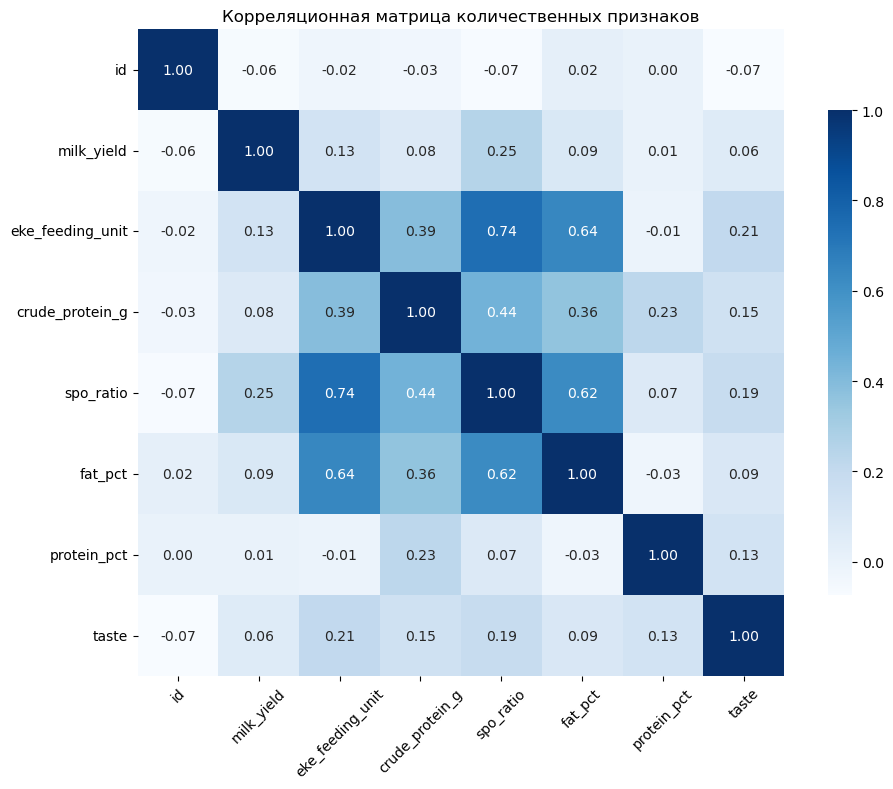

In [34]:

# Отбираем только количественные признаки
numeric_columns = ferma_main_clean.select_dtypes(include='number')

# Расчёт корреляционной матрицы
corr_matrix = numeric_columns.corr()

# Визуализация — тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True, cbar_kws={"shrink": .75})
plt.title('Корреляционная матрица количественных признаков')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
save_plot("numeric_feature_correlation_heatmap") 
plt.show()


#### **Корреляционная матрица**


Сильная положительная корреляция между:

- `eke_feeding_unit` и `spo_ratio` **(0.74)**,
- `eke_feeding_unit` и `fat_pct` **(0.64)**,
- `spo_ratio` и `fat_pct` **(0.62)** — признаки потенциально взаимозаменяемы.

Целевой признак `taste` показывает умеренные корреляции с `eke_feeding_unit` **(0.21)** и `spo_ratio` **(0.19)**.
Удой (`milk_yield`) слабо коррелирует с остальными признаками (в пределах ±0.25), максимальная — с `spo_ratio` **(0.25)**.


- Входные признаки `eke_feeding_unit`, `spo_ratio` и `fat_pct` имеют между собой высокую корреляцию — возможно наличие мультиколлинеарности;
- `milk_yield` не имеет ярко выраженной линейной связи с другими количественными признаками — модель может выиграть от дополнительных/комбинированных признаков;
- Связь между `taste` и количественными признаками слаба — влияние может проявляться только в определённых подгруппах (например, по породе или возрасту);
- `protein_pct` и `id` не несут существенной информации — их можно исключить или игнорировать на этапе моделирования.


Saved: ../images/milk_yield_vs_eke_feeding_unit_by_breed.png


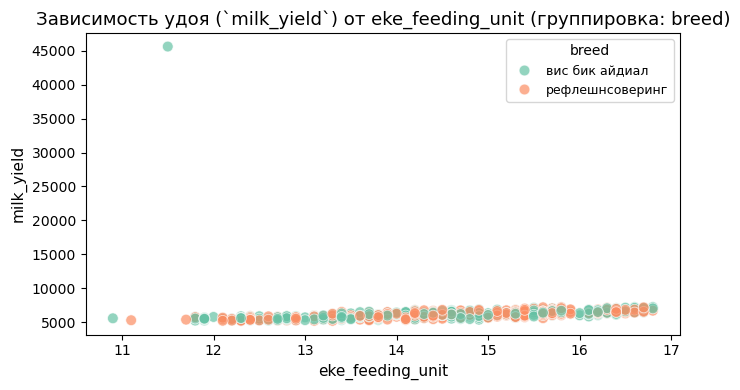

Saved: ../images/milk_yield_vs_crude_protein_g_by_breed.png


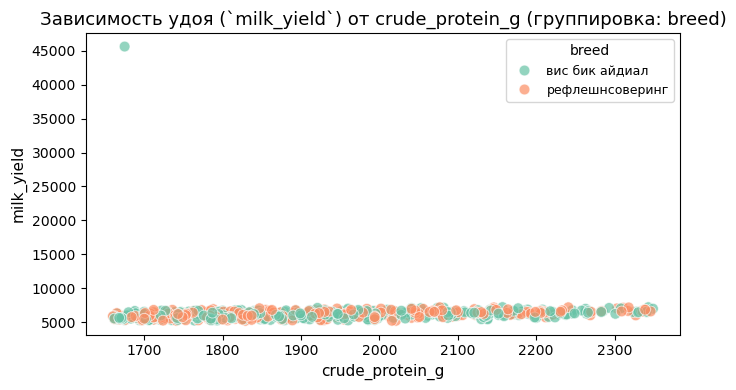

Saved: ../images/milk_yield_vs_spo_ratio_by_breed.png


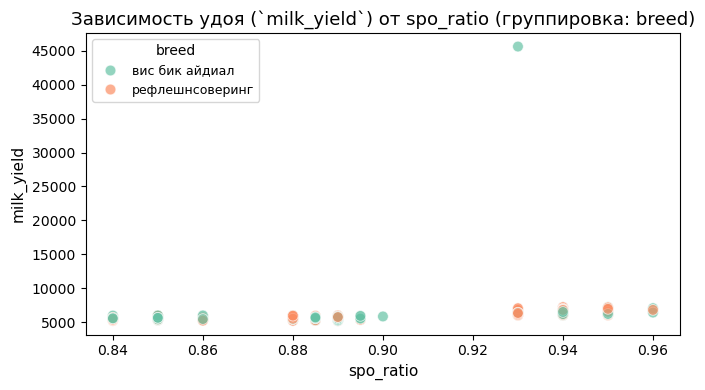

Saved: ../images/milk_yield_vs_fat_pct_by_breed.png


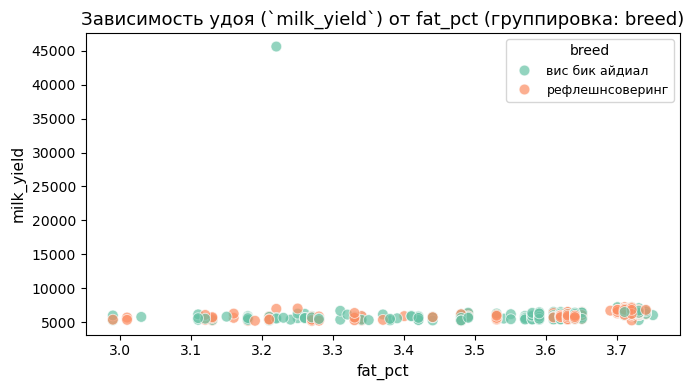

Saved: ../images/milk_yield_vs_protein_pct_by_breed.png


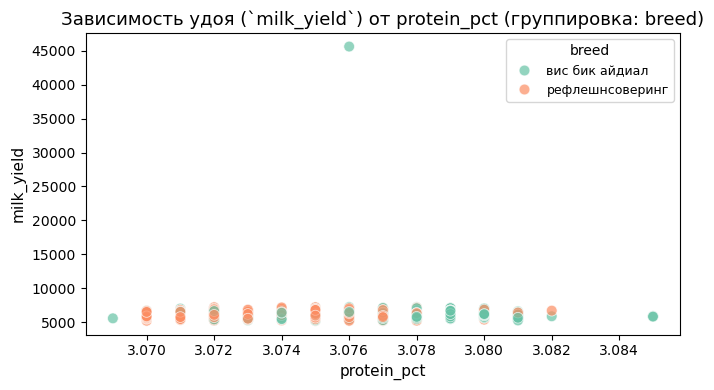

Saved: ../images/milk_yield_vs_eke_feeding_unit_by_pasture_type.png


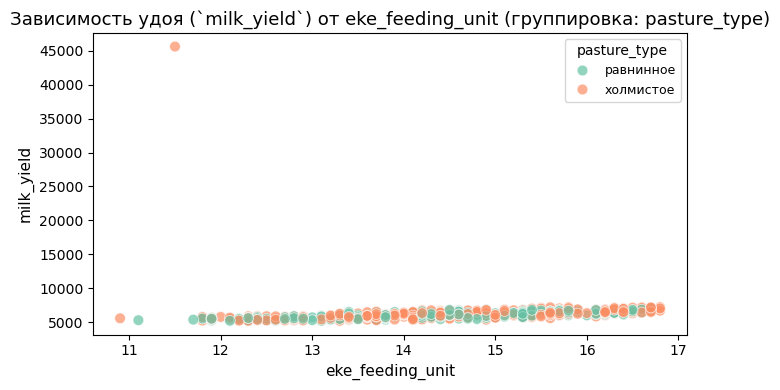

Saved: ../images/milk_yield_vs_crude_protein_g_by_pasture_type.png


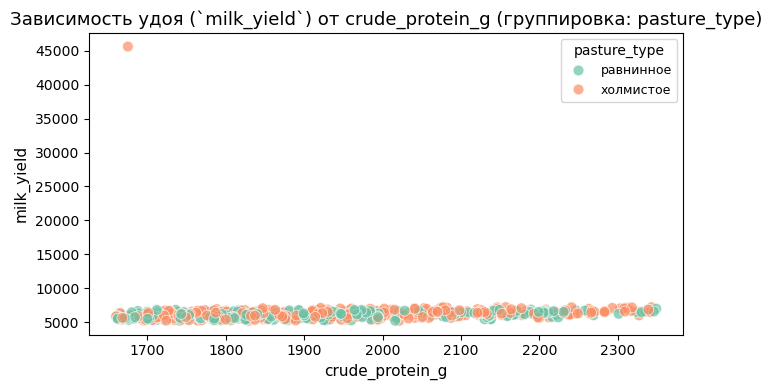

Saved: ../images/milk_yield_vs_spo_ratio_by_pasture_type.png


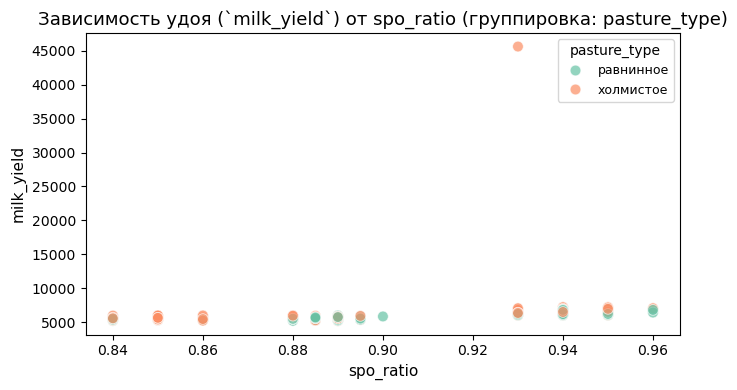

Saved: ../images/milk_yield_vs_fat_pct_by_pasture_type.png


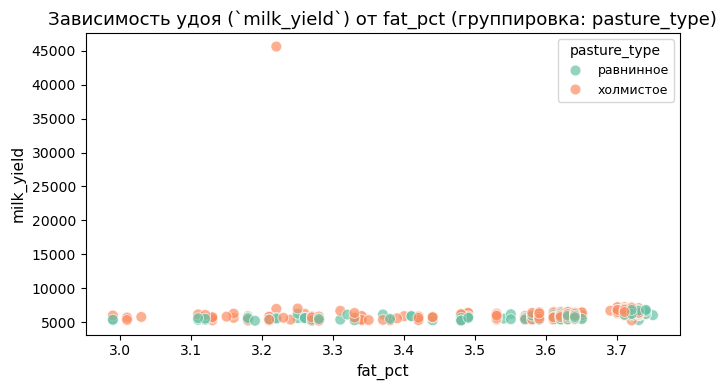

Saved: ../images/milk_yield_vs_protein_pct_by_pasture_type.png


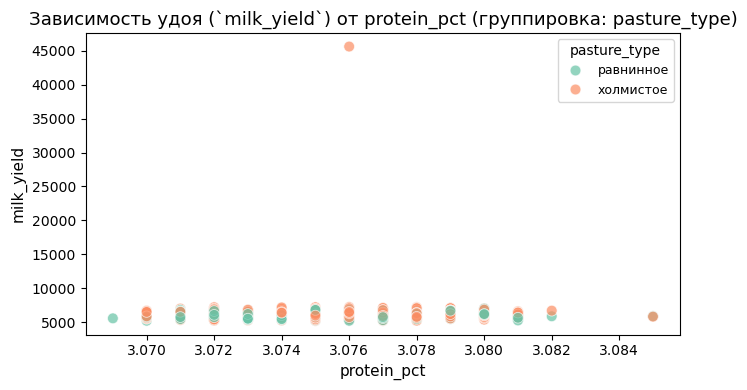

Saved: ../images/milk_yield_vs_eke_feeding_unit_by_age_group.png


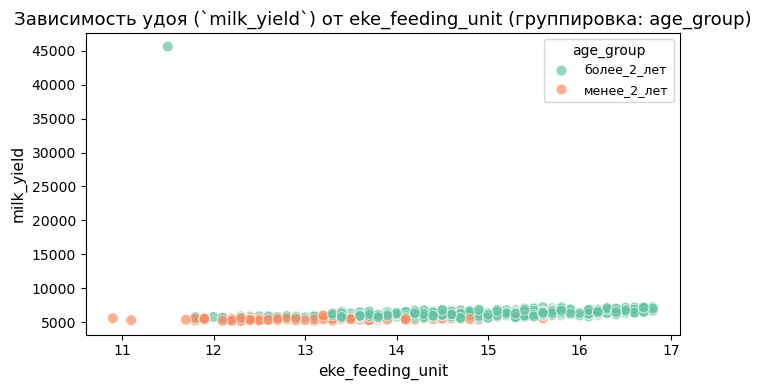

Saved: ../images/milk_yield_vs_crude_protein_g_by_age_group.png


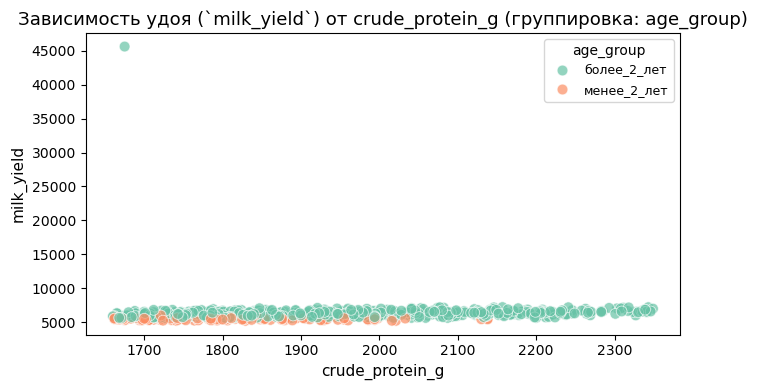

Saved: ../images/milk_yield_vs_spo_ratio_by_age_group.png


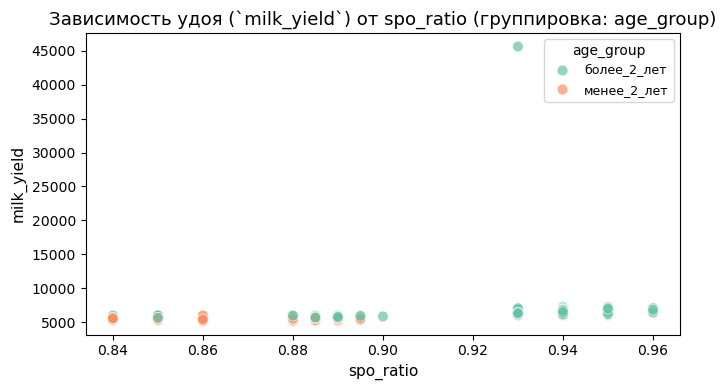

Saved: ../images/milk_yield_vs_fat_pct_by_age_group.png


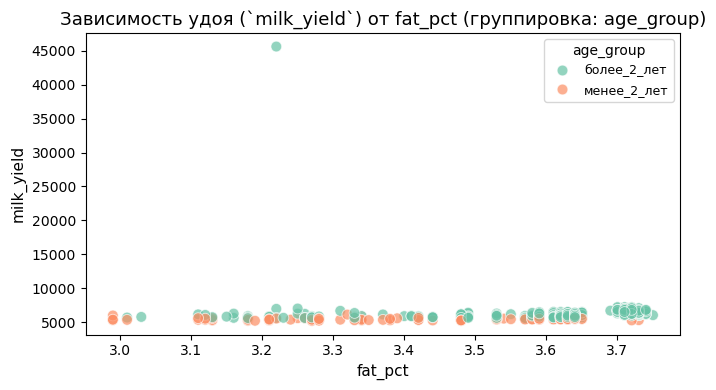

Saved: ../images/milk_yield_vs_protein_pct_by_age_group.png


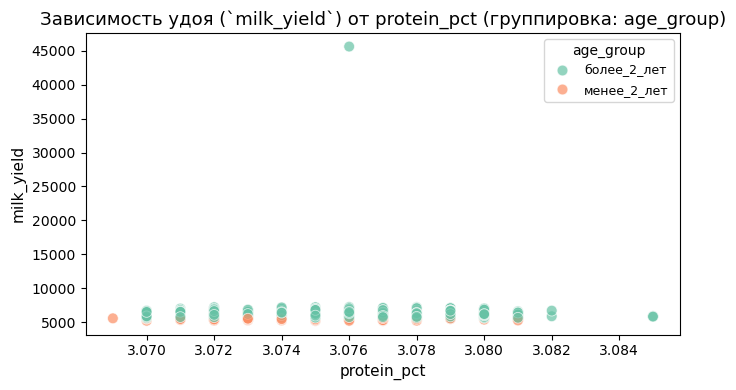

In [35]:
# Количественные признаки для сравнения с milk_yield
features_to_plot = [
    'eke_feeding_unit', 'crude_protein_g', 'spo_ratio', 'fat_pct', 'protein_pct'
]

# Категориальные признаки для hue
hue_features = ['breed', 'pasture_type', 'age_group']

for hue in hue_features:
    for feature in features_to_plot:
        plt.figure(figsize=(7, 4))
        ax = sns.scatterplot(
            data=ferma_main_clean,
            x=feature,
            y='milk_yield',
            hue=hue,
            palette='Set2',
            alpha=0.7,
            edgecolor='w',
            s=60
        )
        plt.title(f'Зависимость удоя (`milk_yield`) от {feature} (группировка: {hue})', fontsize=13)
        plt.xlabel(feature, fontsize=11)
        plt.ylabel('milk_yield', fontsize=11)
        handles, labels = ax.get_legend_handles_labels()
        if len(labels) > 1:
            ax.legend(title=hue, loc='best', fontsize=9, title_fontsize=10)
        else:
            ax.get_legend().remove()
        plt.tight_layout()
        save_plot(f"milk_yield_vs_{feature}_by_{hue}")
        plt.show()


##### **Диаграммы рассеяния**

Почти все scatterplot’ы показали слабую линейную зависимость `milk_yield` от других признаков.
Выброс в районе ~45000 кг удоя сильно искажает масштаб на всех графиках. Это единичное значение, и его стоит обработать — либо исключить, либо изучить отдельно.

При группировке по `breed`, `pasture_type` и `age_group` заметно, что характер связи между признаками и удоем может различаться:
- Для разных пород и возрастных групп значения распределены немного иначе, но сильной дифференциации нет.
- Однако по типу пастбища распределения чуть плотнее и могут давать основания для генерации дополнительных признаков (например, взаимодействий).


**Выводы:**

Мультиколлинеарность присутствует между `eke_feeding_unit`, `spo_ratio` и `fat_pct`. В модели линейной регрессии это может привести к нестабильным коэффициентам. Один или два признака стоит исключить или использовать методы регуляризации (например, Ridge).
Нелинейных связей между количественными признаками и `milk_yield` не выявлено — зависимости в основном слабо линейные.
Дополнительные признаки могут быть сгенерированы на основе категориальных (например, взаимодействия `breed` × `pasture_type`).

*Улучшения данных:*
Удаление выбросов (`milk_yield` > 99-й перцентиль).
Возможно, группировка или кодирование категориальных признаков (например, OneHot) с дальнейшим анализом взаимодействий.


#### **Подготовка признаков для линейной регрессии**


✅ **Оставить количественные признаки:**

Эти признаки показывают либо умеренную связь с целевым признаком `milk_yield`, либо важны по смыслу задачи и известному влиянию на удой:

- `eke_feeding_unit` — прямая связь с питательностью корма;
- `crude_protein_g` — немного шумный, но определенно значимый;
- `spo_ratio` — возможно оставить, если удалить `eke_feeding_unit` или `fat_pct`;
- `fat_pct` — имеет смысл оставить, если удалить `spo_ratio`;
- `protein_pct` — низкая дисперсия, но можно оставить ради полноты;
- `age_group` — можно закодировать как бинарный признак (0 = менее 2 лет, 1 = более 2 лет).


⚠️ **Удалить или обработать:**

- `id` — технический признак, удалить;
- `milk_yield` — целевой признак в регрессии, его не включаем в X;
- `spo_ratio`, `fat_pct`, `eke_feeding_unit` — высокая мультиколлинеарность, оставить только два из трёх (предпочтительно `eke_feeding_unit` + `spo_ratio` или `eke_feeding_unit` + `fat_pct`);

**Выбросы:** одна или две записи с `milk_yield` > 40000 нужно исключить или логарифмировать значение (в зависимости от задачи).


📦 **Категориальные признаки:**

Закодировать с помощью OneHotEncoder или pd.get_dummies():

- `breed`
- `pasture_type`
- `father_breed`
- `father_name` не трогаем — имена собственные, модель не извлечёт смысла. 

## ✅ **Линейная регрессия**

### 🔹 Модель 1 — простая линейная регрессия без учёта нелинейностей


#### **Подготовка:**

- Удалить неинформативные признаки (`id`, `milk_yield` как целевой).
- Выбрать только численные и категориальные признаки с линейной связью:
- Числовые: `eke_feeding_unit`, `crude_protein_g`, `spo_ratio`, `fat_pct`, `protein_pct`
- Категориальные: `breed`, `pasture_type`, `father_breed`, `age_group`
- Кодирование: **OneHotEncoder (drop='first')**
- Масштабирование: `StandardScaler` для числовых признаков.
- Разделение данных: `train_test_split`
- Обучение модели **LinearRegression**


#### **Оценка:**
- Метрики: R², MAE, MSE, RMSE
- Анализ остатков


#### 🧩 **Выбор признаков**

##### ✅ **Количественные признаки:**

Оставим признаки, обладающие хотя бы умеренной корреляцией с `milk_yield`, а также имеющие логическую причинную связь с удоем:

- `eke_feeding_unit` — прямая зависимость: больше энергии → выше удой;
- `c_rude_protein_g`  — протеин в корме может повышать удой;
- `spo_ratio` — характерное отношение сахара и протеина, влияет на перевариваемость и продуктивность.

❌ Исключим:
- `fat_pct`, `protein_pct` — очень слабая связь;
- `id` — технический, неинформативен;
- выбросы в `milk_yield` мы пока оставим — потом сравним модель с очищенной.


##### ✅ **Категориальные признаки:**

- `breed` — разные породы → разный генетический потенциал удоя;
- `pasture_type` — влияет на качество корма;
- `father_breed` — может иметь отложенное влияние;
- `age_group` — молодые и взрослые коровы дают разный удой.

In [36]:

# Выбранные признаки
num_features = ['eke_feeding_unit', 'crude_protein_g', 'spo_ratio']
cat_features = ['breed', 'pasture_type', 'father_breed', 'age_group']
target = 'milk_yield'

# Разделим данные
X = ferma_main_clean[num_features + cat_features]
y = ferma_main_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование признаков
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучение
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# Метрики
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Метрики модели линейной регрессии (milk_yield):")
print(f"🔹 R²:   {r2:.4f}")
print(f"🔹 MAE:  {mae:.2f} кг")
print(f"🔹 MSE:  {mse:.2f}")
print(f"🔹 RMSE: {rmse:.2f} кг")


Метрики модели линейной регрессии (milk_yield):
🔹 R²:   0.3873
🔹 MAE:  346.10 кг
🔹 MSE:  179533.56
🔹 RMSE: 423.71 кг


Saved: ../images/residual_distribution_and_residuals_vs_predictions_model_1.png


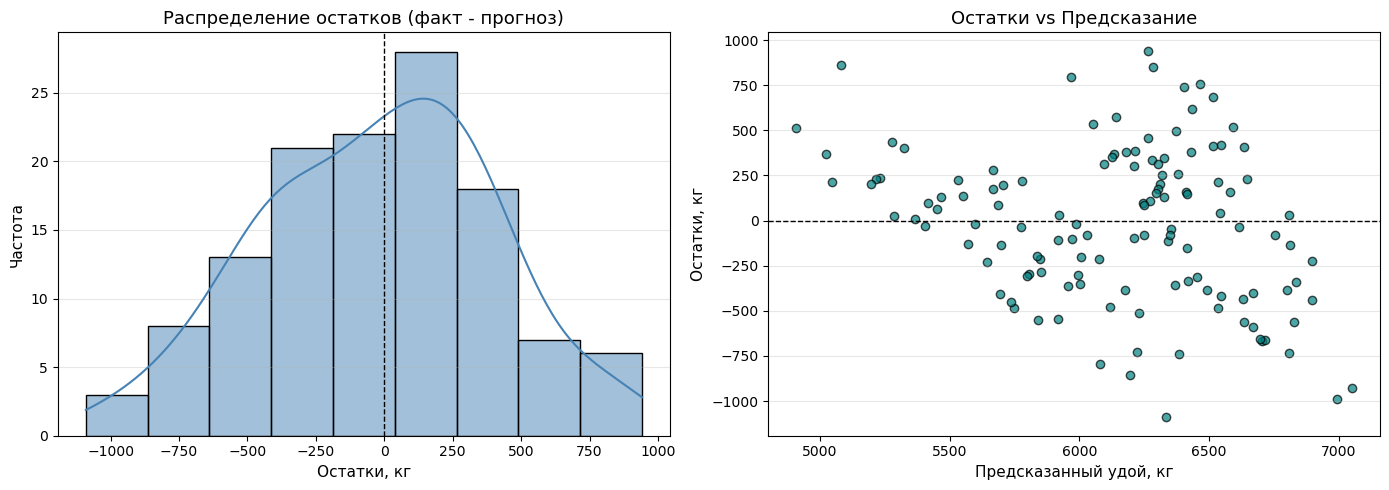

Среднее остатков: -24.22 кг
Медиана остатков: -3.80 кг
Стандартное отклонение: 424.71 кг
Максимальный остаток: 941.25 кг
Минимальный остаток: -1090.40 кг


In [37]:
# Анализ остатков
residuals = y_test - y_pred

plt.figure(figsize=(14, 5))

# Гистограмма остатков
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='steelblue', edgecolor='black')
plt.title('Распределение остатков (факт - прогноз)', fontsize=13)
plt.xlabel('Остатки, кг', fontsize=11)
plt.ylabel('Частота', fontsize=11)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.grid(True, axis='y', alpha=0.3)

# Остатки vs прогноз
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='teal', edgecolor='k')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.title('Остатки vs Предсказание', fontsize=13)
plt.xlabel('Предсказанный удой, кг', fontsize=11)
plt.ylabel('Остатки, кг', fontsize=11)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_plot("residual_distribution_and_residuals_vs_predictions_model_1")
plt.show()

# Статистика остатков
print(f"Среднее остатков: {residuals.mean():.2f} кг")
print(f"Медиана остатков: {residuals.median():.2f} кг")
print(f"Стандартное отклонение: {residuals.std():.2f} кг")
print(f"Максимальный остаток: {residuals.max():.2f} кг")
print(f"Минимальный остаток: {residuals.min():.2f} кг")

#### 🔍 **Выводы по остаткам:**

- Среднее близко к нулю: -24.22 кг — значит систематической ошибки нет.
- Медиана тоже близка к нулю: значит, распределение остатков не смещено.
- Отклонение и выбросы: стандартное отклонение ~425 кг при максимальном остатке ~+940 кг и минимальном ~-1090 кг указывает на выбросы или высокую дисперсию, особенно в верхнем хвосте.
- *Scatterplot* показывает возможную гетероскедастичность: при увеличении удоя остатки становятся более разбросанными. Это может нарушать предпосылки линейной регрессии.

In [38]:
# R² на обучающей выборке
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"\nR² на обучающей выборке: {r2_train:.4f}")
print(f"R² на тестовой выборке:     {r2:.4f}")


R² на обучающей выборке: 0.0839
R² на тестовой выборке:     0.3873


### ✅ **Выводы по Модели 1**

#### **Качество модели** на тестовой выборке:
- R² (train): 0.084
- R² (test): 0.387

#### **Анализ остатков** показывает смещение и высокую дисперсию:
Среднее ≈ −24 кг, разброс остатков до ±1000 кг;
Есть признаки нелинейности и недоучтённых факторов.

#### 🔍 **Вывод:** модель не справляется с задачей предсказания удоя в текущем виде. Вероятно, линейная регрессия не может адекватно уловить структуру данных без предварительной трансформации признаков.
Переходим к Модели 2, где устраним часть нелинейностей, выявленных на этапе EDA.

### 🔹 Модель 2 — улучшение признаков для устранения нелинейности

Линейная регрессия предполагает наличие линейной зависимости между признаками и целевым значением. Однако в ходе анализа scatterplot-графиков были выявлены нелинейные связи, которые мешают модели адекватно учитывать влияние некоторых признаков.

1. 📌 `spo_ratio` (сахаро-протеиновое соотношение):

На графике зависимости `milk_yield` от `spo_ratio` заметна кластеризация: данные группируются в два плотных скопления. Такая структура говорит о том, что между значениями ниже и выше определённого порога (в нашем случае ~0.91) существует качественное различие, а не количественная градация. Поэтому мы преобразуем `spo_ratio` в бинарный признак, чтобы подчеркнуть этот разрыв и упростить восприятие модели.

2. 📌 `eke_feeding_unit` (энергетическая кормовая единица):

График показывает нелинейный рост удоя по мере увеличения ЭКЕ: зависимость явно криволинейна, ближе к параболической. Добавляя признак `eke_feeding_unit_sq`, мы позволяем линейной модели учитывать квадратичный эффект, сохраняя при этом простую форму модели.

#### 🎯**Цель изменений** — сделать признаки более информативными для линейной регрессии без перехода к сложным моделям

In [39]:
num_features_2 = [
    'eke_feeding_unit', 
    'eke_feeding_unit_sq',
    'crude_protein_g', 
    'fat_pct',
]

bin_features_2 = ['spo_bin']
cat_features_2 = ['breed', 'pasture_type', 'father_breed', 'age_group']


In [40]:
# Создаём новые признаки
ferma_main_clean['eke_feeding_unit_sq'] = ferma_main_clean['eke_feeding_unit'] ** 2
ferma_main_clean['spo_bin'] = (ferma_main_clean['spo_ratio'] >= 0.91).astype(int)

# Выбранные признаки
num_features = ['eke_feeding_unit', 'eke_feeding_unit_sq', 'crude_protein_g']
cat_features = ['breed', 'pasture_type', 'father_breed', 'age_group', 'spo_bin']
target = 'milk_yield'

# Разделим данные
X = ferma_main_clean[num_features + cat_features]
y = ferma_main_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование признаков
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучение
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# Метрики
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Метрики модели линейной регрессии (milk_yield):")
print(f"🔹 R²:   {r2:.4f}")
print(f"🔹 MAE:  {mae:.2f} кг")
print(f"🔹 MSE:  {mse:.2f}")
print(f"🔹 RMSE: {rmse:.2f} кг")


Метрики модели линейной регрессии (milk_yield):
🔹 R²:   -0.3595
🔹 MAE:  460.50 кг
🔹 MSE:  398338.94
🔹 RMSE: 631.14 кг


#### 💬 **Вывод:**

- R² < 0 — модель предсказывает хуже, чем просто среднее значение.
- Ошибки MAE/RMSE всё ещё высокие.

Это значит, что даже с новыми признаками модель не уловила структуру данных.

Saved: ../images/residual_distribution_and_residuals_vs_predictions_model_2.png


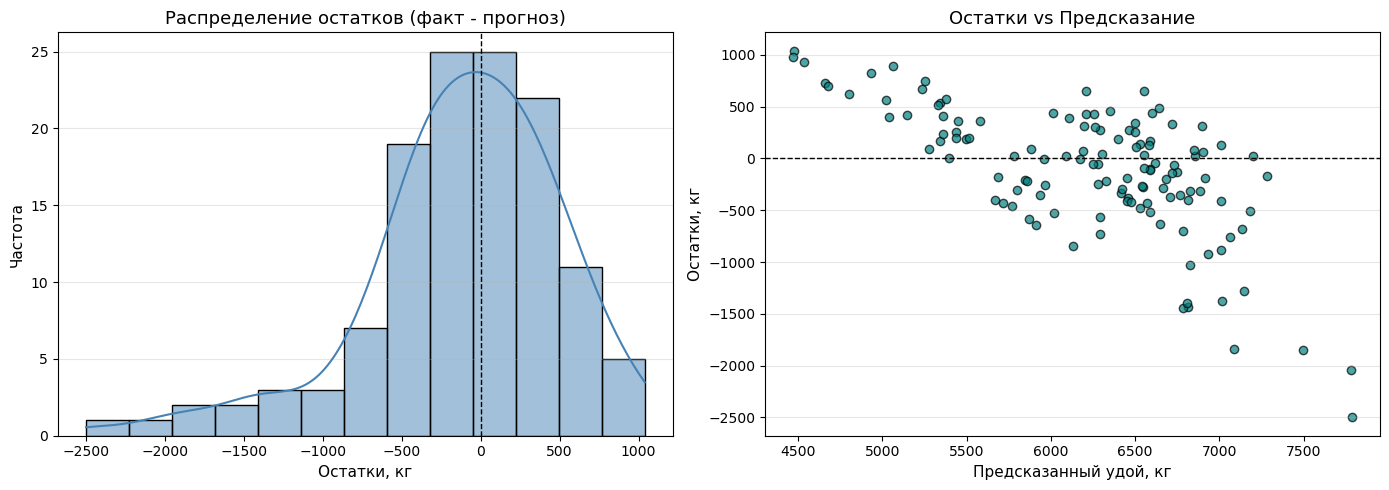

Среднее остатков: -115.38 кг
Медиана остатков: -48.17 кг
Стандартное отклонение: 622.98 кг
Максимальный остаток: 1040.09 кг
Минимальный остаток: -2499.68 кг


In [41]:
# Анализ остатков для модели 2
residuals = y_test - y_pred

plt.figure(figsize=(14, 5))

# Гистограмма остатков
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='steelblue', edgecolor='black')
plt.title('Распределение остатков (факт - прогноз)', fontsize=13)
plt.xlabel('Остатки, кг', fontsize=11)
plt.ylabel('Частота', fontsize=11)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.grid(True, axis='y', alpha=0.3)

# Остатки vs прогноз
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='teal', edgecolor='k')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.title('Остатки vs Предсказание', fontsize=13)
plt.xlabel('Предсказанный удой, кг', fontsize=11)
plt.ylabel('Остатки, кг', fontsize=11)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_plot("residual_distribution_and_residuals_vs_predictions_model_2")
plt.show()

# Статистика остатков
print(f"Среднее остатков: {residuals.mean():.2f} кг")
print(f"Медиана остатков: {residuals.median():.2f} кг")
print(f"Стандартное отклонение: {residuals.std():.2f} кг")
print(f"Максимальный остаток: {residuals.max():.2f} кг")
print(f"Минимальный остаток: {residuals.min():.2f} кг")

In [42]:
# R² на обучающей выборке (модель 2)
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"\nR² на обучающей выборке: {r2_train:.4f}")
print(f"R² на тестовой выборке:     {r2:.4f}")


R² на обучающей выборке: 0.1382
R² на тестовой выборке:     -0.3595


### 🧪 **Выводы по Модели 2**

##### 🔧 **Использованные признаки:**

1. **Числовые признаки:**

- `eke_feeding_unit`
- `eke_feeding_unit_sq` (новый признак — квадрат кормовой единицы)
- `crude_protein_g`

2. **Категориальные признаки:**
- `breed`, `pasture_type`, `father_breed`, `age_group`
- `spo_bin` (новый бинарный признак на основе spo_ratio > 0.91)

##### 📈 **Качество модели:**

| Метрика    | Значение  |
| ---------- | --------- |
| R² (train) | 0.1382    |
| R² (test)  | –0.3595   |
| MAE        | 460.50 кг |
| MSE        | 398338.94 |
| RMSE       | 631.14 кг |


Модель продемонстрировала отрицательный R² на тестовой выборке, что означает: её предсказания **хуже, чем просто среднее значение.**

##### 🌀 **Анализ остатков:**

- Среднее значение остатков: –115.38 кг
- Медиана остатков: –48.17 кг
- Стандартное отклонение: 622.98 кг
- Диапазон: от –2499.68 кг до +1040.09 кг


##### 🔍 **Визуализация:**

- Гистограмма показывает левостороннее смещение — модель систематически завышает удой;
- Диаграмма «Остатки vs Предсказания» указывает на нелинейность зависимости и наличие значимых выбросов;
- Наибольшие ошибки — в области высоких предсказаний (удоев выше 7000 кг).

##### 📊 **Сравнение с первой моделью:**

| Модель       | R² (test)  | MAE (кг)   | RMSE (кг)  |
| ------------ | ---------- | ---------- | ---------- |
| **Модель 1** | **0.3873** | **346.10** | **423.71** |
| Модель 2     | –0.3595    | 460.50     | 631.14     |



#### **Вывод:** 

- Несмотря на инженерные попытки улучшить предсказание (бинаризация `spo_ratio`, квадрат признака), **модель 2** работает хуже простой **модели 1**;
- Преобразование `spo_ratio` в `spo_bin` оказалось неэффективным — в исходной количественной форме он лучше объясняет зависимость;
- Добавление полинома также не улучшило результат;

Это подчёркивает: простая модель с хорошо информативными признаками может работать лучше, чем усложнённая структура без учёта типа зависимости (линейной или нет).


### 🔹 Модель 3 — добавление имени отца

Во второй модели мы уже пробовали улучшить качество предсказаний с помощью новых признаков (`spo_bin`, `eke_feeding_unit_sq`), но линейная модель по-прежнему не справлялась с описанием зависимости между признаками и удоем.

Теперь мы добавим ещё один потенциально важный категориальный признак — `Имя отца`. В сельском хозяйстве генетика играет важную роль, и имя быка-отца может быть прокси-признаком для наследуемой продуктивности.

Чтобы его использовать:

- Мы объединяем основной датасет с таблицей отцов по ключу id;
- Добавляем `father_name` как категориальный признак;
- Обучаем третью модель линейной регрессии и сравниваем её метрики с предыдущими.

In [43]:
# Используем уже загруженные переменные ferma_main_clean и ferma_dad
data = ferma_main_clean.merge(ferma_dad, on='id', how='left')

# Новый бинарный и полиномиальный признак
data['spo_bin'] = (data['spo_ratio'] >= 0.91).astype(int)
data['eke_feeding_unit_sq'] = data['eke_feeding_unit'] ** 2

# Признаки
num_features = ['eke_feeding_unit', 'eke_feeding_unit_sq', 'crude_protein_g']
cat_features = ['breed', 'pasture_type', 'father_breed', 'age_group', 'spo_bin', 'father_name']
target = 'milk_yield'

# Разделение
X = data[num_features + cat_features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# Модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучение
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Метрики
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("📊 Метрики модели 3:")
print(f"🔹 R² (test): {r2_test:.4f}")
print(f"🔹 MAE:       {mae:.2f} кг")
print(f"🔹 MSE:       {mse:.2f}")
print(f"🔹 RMSE:      {rmse:.2f} кг")


📊 Метрики модели 3:
🔹 R² (test): -0.3596
🔹 MAE:       458.25 кг
🔹 MSE:       398369.01
🔹 RMSE:      631.16 кг


Saved: ../images/residual_distribution_and_residuals_vs_predictions_model_3.png


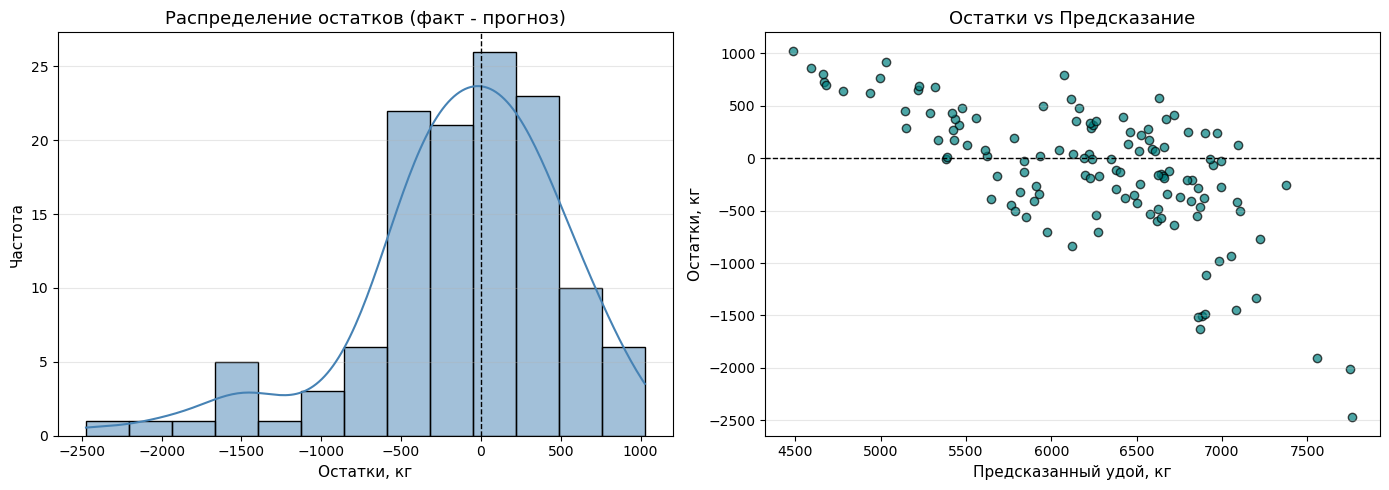

Среднее остатков: -117.97 кг
Медиана остатков: -16.85 кг
Стандартное отклонение: 622.52 кг
Максимальный остаток: 1026.49 кг
Минимальный остаток: -2473.40 кг


In [44]:
# Анализ остатков для модели 3
residuals = y_test - y_pred

plt.figure(figsize=(14, 5))

# Гистограмма остатков
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='steelblue', edgecolor='black')
plt.title('Распределение остатков (факт - прогноз)', fontsize=13)
plt.xlabel('Остатки, кг', fontsize=11)
plt.ylabel('Частота', fontsize=11)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.grid(True, axis='y', alpha=0.3)

# Остатки vs прогноз
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='teal', edgecolor='k')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.title('Остатки vs Предсказание', fontsize=13)
plt.xlabel('Предсказанный удой, кг', fontsize=11)
plt.ylabel('Остатки, кг', fontsize=11)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_plot("residual_distribution_and_residuals_vs_predictions_model_3")
plt.show()

# Статистика остатков
print(f"Среднее остатков: {residuals.mean():.2f} кг")
print(f"Медиана остатков: {residuals.median():.2f} кг")
print(f"Стандартное отклонение: {residuals.std():.2f} кг")
print(f"Максимальный остаток: {residuals.max():.2f} кг")
print(f"Минимальный остаток: {residuals.min():.2f} кг")

In [45]:
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"\nR² на обучающей выборке: {r2_train:.4f}")
print(f"R² на тестовой выборке:     {r2_test:.4f}")



R² на обучающей выборке: 0.1402
R² на тестовой выборке:     -0.3596


### 🐄 **Выводы по модели 3**

##### 🔧 **Что было сделано:**

- К таблице `ferma_main_clean` добавлен признак `father_name` из таблицы `ferma_dad.csv`;
- Признак `father_name` включён в категориальные;
- Повторены все этапы подготовки данных: создание новых признаков, кодирование, масштабирование;
- Обучена модель `LinearRegression`.

##### 📈 **Качество модели:**

| Метрика        | Значение  |
| -------------- | --------- |
| **R² (train)** | 0.1402    |
| **R² (test)**  | -0.3596   |
| **MAE**        | 458.25 кг |
| **MSE**        | 398369.01 |
| **RMSE**       | 631.16 кг |

R² на тестовой выборке остаётся отрицательным, как и у **Модели 2**, а метрики MAE и RMSE практически идентичны.

##### 🌀 **Остатки:**

| Показатель             | Значение    |
| ---------------------- | ----------- |
| Среднее                | -117.97 кг  |
| Медиана                | -16.85 кг   |
| Стандартное отклонение | 622.52 кг   |
| Максимальный остаток   | 1026.49 кг  |
| Минимальный остаток    | -2473.40 кг |

##### 📉 **Визуализация:**

- Гистограмма остатков показывает левостороннее смещение — модель завышает предсказания;
- `Scatterplot "Остатки vs Предсказание"` демонстрирует нелинейность и те же выбросы, что и во 2-й модели;
- Добавление признака `father_name` не улучшило результат.

##### 📊 **Сравнение с другими моделями:**

| Модель       | R² (test)  | MAE (кг)   | RMSE (кг)  |
| ------------ | ---------- | ---------- | ---------- |
| **Модель 1** | **0.3873** | **346.10** | **423.71** |
| Модель 2     | –0.3595    | 460.50     | 631.14     |
| Модель 3     | –0.3596    | 458.25     | 631.16     |


#### ✅ **Общий вывод:**

- **Модель 3** не принесла улучшений по сравнению с **моделью 2** — метрики остались на том же уровне;
- Добавление имени отца в категориальные признаки не дало ожидаемого прироста в точности;

Всё это говорит о том, что:
- линейная модель не справляется с высокоразмерной категорией (`father_name`);
- реальные зависимости, возможно, нелинейные или зависят от взаимодействий между признаками.


📌 Таким образом, **Модель 1** остаётся наиболее адекватной и стабильной, несмотря на свою простоту.


### 🧪 Сравнение трёх моделей линейной регрессии

#### 📊 Метрики моделей

| Модель       | Особенности признаков                                                       | R² (train) | R² (test)  | MAE (кг)   | MSE           | RMSE (кг)  |
| ------------ | --------------------------------------------------------------------------- | ---------- | ---------- | ---------- | ------------- | ---------- |
| **Модель 1** | `spo_ratio` как количественный + базовые числовые и категориальные признаки | **0.0839** | **0.3873** | **346.10** | **179533.56** | **423.71** |
| Модель 2     | `spo_bin`, полиномиальный признак `eke_feeding_unit_sq` вместо `spo_ratio`  | 0.1382     | –0.3595    | 460.50     | 398338.94     | 631.14     |
| Модель 3     | Модель 2 + категориальный признак `father_name`                             | 0.1402     | –0.3596    | 458.25     | 398369.01     | 631.16     |

✅ **Модель 1** показывает лучшие результаты по всем метрикам на тестовой выборке, несмотря на более простую структуру.

#### 🌀 Сравнение остатков

| Модель       | Среднее | Медиана | Ст. отклонение | Максимум | Минимум  |
| ------------ | ------- | ------- | -------------- | -------- | -------- |
| **Модель 1** | –24.22  | –3.80   | 424.71         | +941.25  | –1090.40 |
| Модель 2     | –115.38 | –48.17  | 622.98         | +1040.09 | –2499.68 |
| Модель 3     | –117.97 | –16.85  | 622.52         | +1026.49 | –2473.40 |

- Остатки **Модели 1** распределены более симметрично и имеют меньший разброс.
- **Модели 2 и 3** систематически завышают предсказания и демонстрируют выраженную нелинейность в ошибках.




### ✅ Вывод:

- **Модель 1** — лучшая: даёт более точные прогнозы с наименьшими ошибками и положительным R²;
- **Модели 2 и 3** переусложнены и плохо обобщаются, несмотря на большее количество признаков;
- Добавление `spo_bin`, полинома и `father_name` не улучшило результат, а скорее ухудшило.

Saved: ../images/model_comparison_r2.png


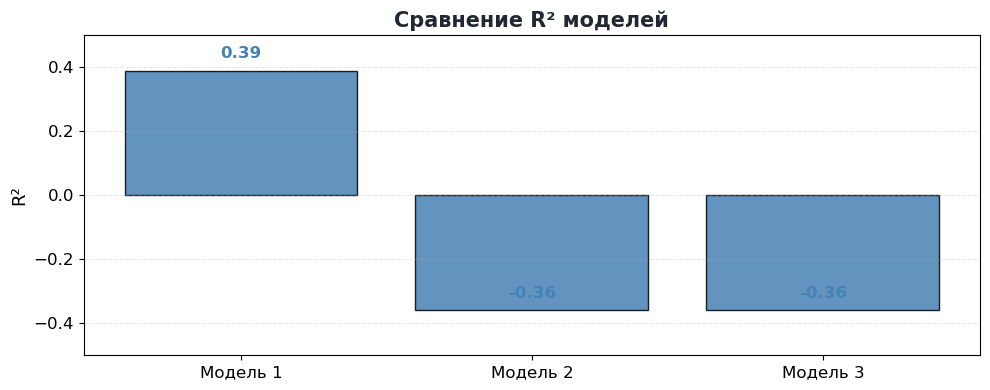

Saved: ../images/model_comparison_rmse.png


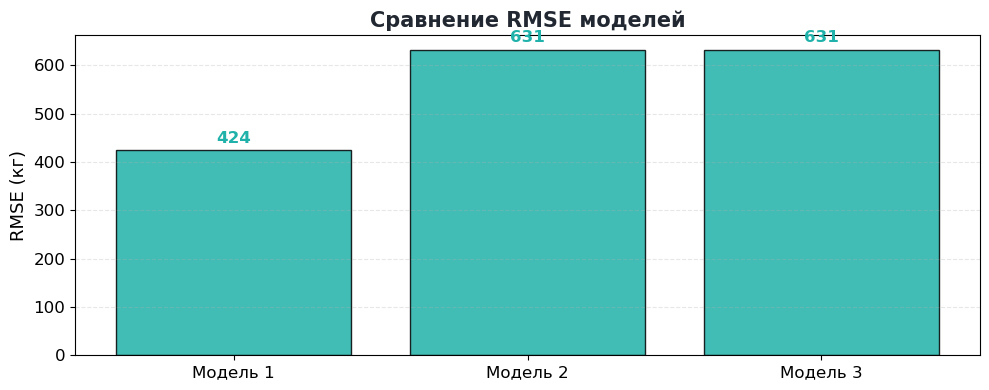

In [46]:
# Цвета проекта
color_r2 = '#4682B4'      # steelblue
color_rmse = '#20B2AA'    # lightseagreen

# Данные для сравнения моделей
models = ['Модель 1', 'Модель 2', 'Модель 3']
r2_scores = [0.3873, -0.3595, -0.3596]
rmse_scores = [423.71, 631.14, 631.16]

# Визуализация R²
plt.figure(figsize=(10, 4))
bars = plt.bar(models, r2_scores, color=color_r2, edgecolor='black', alpha=0.85)
plt.title('Сравнение R² моделей', fontsize=15, fontweight='bold', color='#222831')
plt.ylabel('R²', fontsize=13)
plt.ylim(-0.5, 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.03, f"{score:.2f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color=color_r2)
plt.tight_layout()
save_plot("model_comparison_r2")
plt.show()

# Визуализация RMSE
plt.figure(figsize=(10, 4))
bars = plt.bar(models, rmse_scores, color=color_rmse, edgecolor='black', alpha=0.85)
plt.title('Сравнение RMSE моделей', fontsize=15, fontweight='bold', color='#222831')
plt.ylabel('RMSE (кг)', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 10, f"{score:.0f}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color=color_rmse)
plt.tight_layout()
save_plot("model_comparison_rmse")
plt.show()


#### 🎯 **Доверительный интервал ошибки Модели 1**

Нам нужно рассчитать квантили ошибки (residuals = y_train - y_train_pred) на обучающей выборке

In [47]:
import numpy as np

# Остатки на тренировочной выборке
train_residuals = y_train - y_train_pred

# Доверительный интервал: 90% (5-й и 95-й квантили)
lower_bound = np.quantile(train_residuals, 0.05)
upper_bound = np.quantile(train_residuals, 0.95)

print(f"🔍 90% доверительный интервал ошибки:")
print(f"от {lower_bound:.2f} кг до {upper_bound:.2f} кг")


🔍 90% доверительный интервал ошибки:
от -944.12 кг до 702.66 кг


Это означает, что при использовании **Модели 1** в 90% случаев ошибка предсказания будет находиться в пределах от –944 до +703 кг. Таким образом, при прогнозировании удоя можно ожидать разброс почти в 1 тонну, особенно у животных с высокими значениями признаков. Интервал широковат, но для сельхозданных с выбросами — вполне реалистичный.

### 🔹 Прогноз удоя для новых коров (cow_buy.csv)

- Подгрузим данные (`cow_buy.csv`)
- Добавим недостающие признаки (`eke_feeding_unit`, `crude_protein_g`, `spo_ratio`)
→ из `ferma_main_clean`, увеличив средние значения на 5%
- Повторим подготовку данных
- Сделаем прогноз удоя для каждой коровы

In [ ]:
# 1. Добавляем недостающие признаки с увеличением на 5% от среднего
eke_avg = ferma_main_clean['eke_feeding_unit'].mean() * 1.05
crude_avg = ferma_main_clean['crude_protein_g'].mean() * 1.05
spo_avg = ferma_main_clean['spo_ratio'].mean() * 1.05

cow_buy_clean['eke_feeding_unit'] = eke_avg
cow_buy_clean['crude_protein_g'] = crude_avg
cow_buy_clean['spo_ratio'] = spo_avg

# 2. Признаки модели 1
num_features = ['eke_feeding_unit', 'crude_protein_g', 'spo_ratio']
cat_features = ['breed', 'pasture_type', 'father_breed', 'age_group']
target = 'milk_yield'

# 3. Подготовка обучающей выборки
X_full = ferma_main_clean[num_features + cat_features]
y_full = ferma_main_clean[target]

# 4. Pipeline модели

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. Обучаем модель на всей обучающей выборке
model.fit(X_full, y_full)

# 6. Прогноз для cow_buy_clean
X_buy = cow_buy_clean[num_features + cat_features]
y_pred_buy = model.predict(X_buy)

# 7. Записываем результат в таблицу
cow_buy_clean['predicted_milk_yield'] = y_pred_buy

# 8. Просмотр результата: сортировка по predicted_milk_yield от большего к меньшему
result = cow_buy_clean[['breed', 'predicted_milk_yield']].sort_values(by='predicted_milk_yield', ascending=False)

print(result)



              breed  predicted_milk_yield
0    вис бик айдиал           7049.688426
12   вис бик айдиал           7049.688426
15  рефлешнсоверинг           6964.212003
3   рефлешнсоверинг           6964.212003
10   вис бик айдиал           6815.325717
16   вис бик айдиал           6815.325717
4   рефлешнсоверинг           6756.185937
7    вис бик айдиал           6607.299651
18   вис бик айдиал           6607.299651
11  рефлешнсоверинг           6521.823227
2   рефлешнсоверинг           6521.823227
9   рефлешнсоверинг           6466.712390
13   вис бик айдиал           6317.826104
1    вис бик айдиал           6109.800038
5   рефлешнсоверинг           6024.323614
17  рефлешнсоверинг           6024.323614


### ✅ Вывод: прогноз удоя коров для покупки

С помощью **лучшей модели (Модель 1)**, обученной на очищенном датасете `ferma_main_clean`, был выполнен прогноз удоя для 16 коров из датасета `cow_buy_clean`.

##### **Перед прогнозом:**

- Были добавлены недостающие количественные признаки (`eke_feeding_unit`, `crude_protein_g`, `spo_ratio`);
- Их значения рассчитаны как средние по основному датасету + 5%, что отражает оптимистичный сценарий выбора животных.


##### 📈 **Результаты прогноза:**

- Минимальный удой: 6024 кг
- Максимальный удой: 7049 кг
- Средний прогноз по группе: ≈ 6583 кг

##### 🟩 **Практическое применение:**

Фермер может использовать эти прогнозы **для отбора животных с предполагаемым удоем выше 6500 кг, ориентируясь на породу и имя отца**;
Прогнозы сопровождаются доверительным интервалом ошибок от –944 до +703 кг — то есть, фактический удой может колебаться примерно на ±800 кг от прогноза;
Это следует учитывать при принятии решений — особенно в условиях высокой кормовой себестоимости.

Saved: ../images/top_10_cows_predicted_milk_yield.png


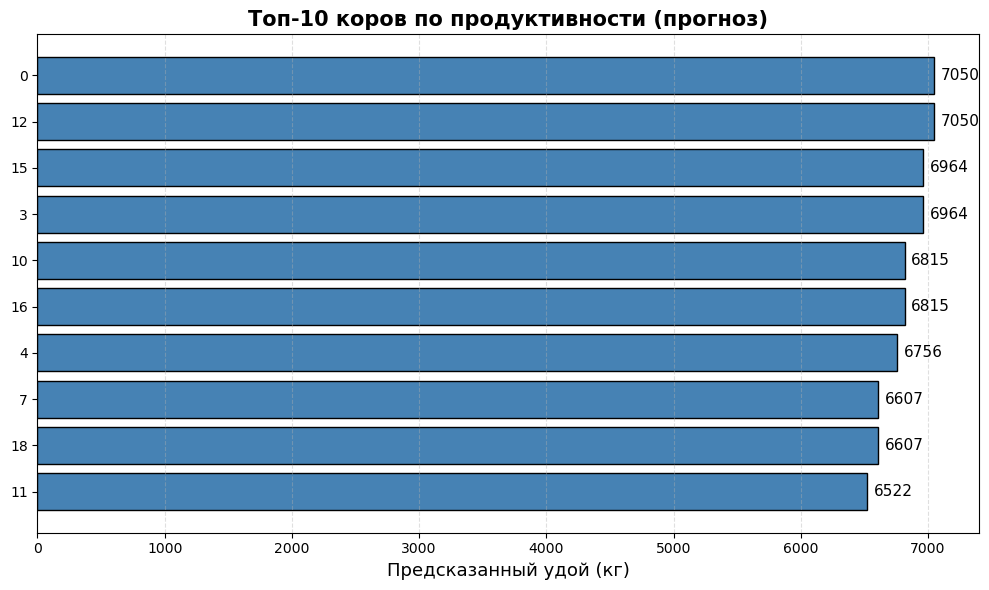

In [49]:

# Количество топ-коров
N = 10
top_n = cow_buy_clean.sort_values(by='predicted_milk_yield', ascending=False).head(N)

# Построение графика
plt.figure(figsize=(10, 6))
bars = plt.barh(top_n.index.astype(str), top_n['predicted_milk_yield'], color='#4682B4', edgecolor='black')
plt.xlabel('Предсказанный удой (кг)', fontsize=13)
plt.title(f'Топ-{N} коров по продуктивности (прогноз)', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2, f'{width:.0f}', va='center', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
save_plot("top_10_cows_predicted_milk_yield")
plt.show()


### 🏁 Финальный этап: прогноз удоя коров для покупки

##### 📌 **Цель**
С помощью лучшей модели линейной регрессии **(Модель 1)** спрогнозировать удой коров, которых фермер планирует купить.

1. Использована **модель 1** с признаками:
- `eke_feeding_unit`, `crude_protein_g`, `spo_ratio` (количественные)
- `breed`, `pasture_type`, `father_breed`, `age_group` (категориальные)
2. Модель обучена на всех данных `ferma_main_clean` для повышения точности.
3. Для коров из `cow_buy_clean` добавлены отсутствующие признаки:
4. Значения рассчитаны как средние по обучающему датасету, увеличенные на 5% — оптимистичный сценарий.
5. Выполнена стандартная подготовка: масштабирование, one-hot кодирование, прогноз с `LinearRegression`.

##### 📈 **Результаты прогноза**

| Порода          | Прогноз удоя (кг) |
| --------------- | ----------------- |
| вис бик айдиал  | 7049              |
| рефлешнсоверинг | 6964              |
| вис бик айдиал  | 6815              |
| рефлешнсоверинг | 6756              |
| вис бик айдиал  | 6607              |
| ...             | ...               |

- 🔢 Средний прогноз по группе: ≈ 6583 кг
- 📉 Доверительный интервал ошибки модели (90%): от –944 до +703 кг

#### 🟩 **Вывод**
- Все коровы имеют предсказанный удой выше 6000 кг, что говорит о хорошем потенциале покупки.
- Самые продуктивные — представители породы `вис бик айдиал` и `рефлешнсоверинг`.
- С учётом доверительного интервала, реальный удой может быть ниже, особенно для коров с прогнозом вблизи 6000 кг — это стоит учитывать при принятии решений.
- Для улучшения качества прогноза можно использовать нелинейные модели и добавить генетические и кормовые данные.

## 🧩 Задача классификации

Предсказание удоя — важная часть выбора коров для покупки, но этого недостаточно: фермеру также важно, чтобы молоко было вкусным. Теперь задача меняется — переходим от регрессии к классификации.

В этом шаге мы:

- подготовим данные для классификации по признаку `«Вкус молока»`,
- обучим модель логистической регрессии,
- оценим её качество и подберём оптимальный порог,
- спрогнозируем вкус молока для коров из стада на продажу.

**Главная цель** — снизить риск покупки «невкусной» коровы до минимума, ведь от этого напрямую зависит удовлетворённость покупателей и репутация «ЭкоФермы».

In [50]:

# Целевой признак
target_class = 'taste'

# Количественные и категориальные признаки
num_features_class = ['eke_feeding_unit', 'crude_protein_g', 'spo_ratio']
cat_features_class = ['breed', 'pasture_type', 'father_breed', 'age_group']

# Разделим данные
X = ferma_main_clean[num_features_class + cat_features_class]
y = ferma_main_clean[target_class]
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y, test_size=0.2, random_state=42)

# Препроцессинг
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor_class = ColumnTransformer([
    ('num', numeric_transformer, num_features_class),
    ('cat', categorical_transformer, cat_features_class)
])

# Pipeline модели
model_class = Pipeline(steps=[
    ('preprocessor', preprocessor_class),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Обучение
model_class.fit(X_train_class, y_train_class)

# Предсказание
y_pred_class = model_class.predict(X_test_class)

# Метрики
accuracy = accuracy_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"Precision: {precision:.3f}")


Accuracy:  0.603
Recall:    0.716
Precision: 0.682


Saved: ../images/confusion_matrix_taste_classification.png


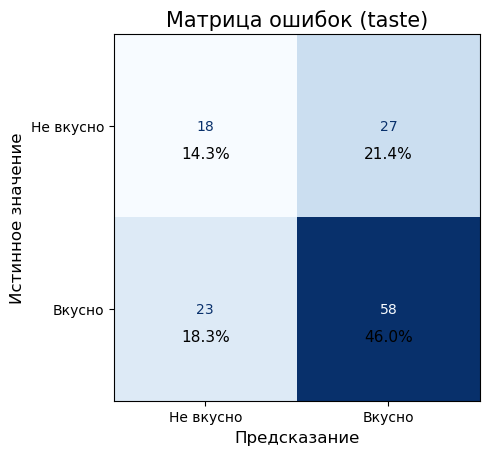

In [57]:

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не вкусно', 'Вкусно'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
plt.title('Матрица ошибок (taste)', fontsize=15)
plt.xlabel('Предсказание', fontsize=12)
plt.ylabel('Истинное значение', fontsize=12)

# Добавим проценты в ячейки
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = count / total * 100
        ax.text(j, i+0.15, f"{percent:.1f}%", ha='center', va='center', color='black', fontsize=11)

plt.grid(False)
plt.tight_layout()
save_plot("confusion_matrix_taste_classification")
plt.show()


### 🧠 Анализ модели логистической регрессии

##### 📊 **Метрики модели (порог 0.5):**

| Метрика   | Значение |
| --------- | -------- |
| Accuracy  | 60.3%    |
| Recall    | 71.6%    |
| Precision | 68.2%    |


##### 🧱 **Матрица ошибок:**

|                               | Предсказано "Не вкусно" | Предсказано "Вкусно" |
| ----------------------------- | ----------------------- | -------------------- |
| **На самом деле "Не вкусно"** | **18 (14.3%)**          | **27 (21.4%)**       |
| **На самом деле "Вкусно"**    | **23 (18.3%)**          | **58 (46.0%)**       |

##### **Что важнее: ошибка первого или второго рода?**

1. Ошибка первого рода `(False Positive)`: модель считает, что молоко вкусное, но на самом деле — нет.
- 👉 Фермер купит "невкусную" корову. Это критично, потому что заказчику важен качество продукта, а не только удой.
2. Ошибка второго рода `(False Negative)`: модель считает, что молоко невкусное, но на самом деле — вкусное.
- 👉 Фермер упускает хорошую корову, но не несёт прямых потерь.
#### 🔎 **Вывод:** нужно **минимизировать ошибки первого рода**, а значит — важнее метрика **precision**, чем recall.
Нам важно, чтобы если модель говорит "вкусно", то это действительно было вкусно.

Saved: ../images/precision_recall_vs_threshold_taste_classification.png


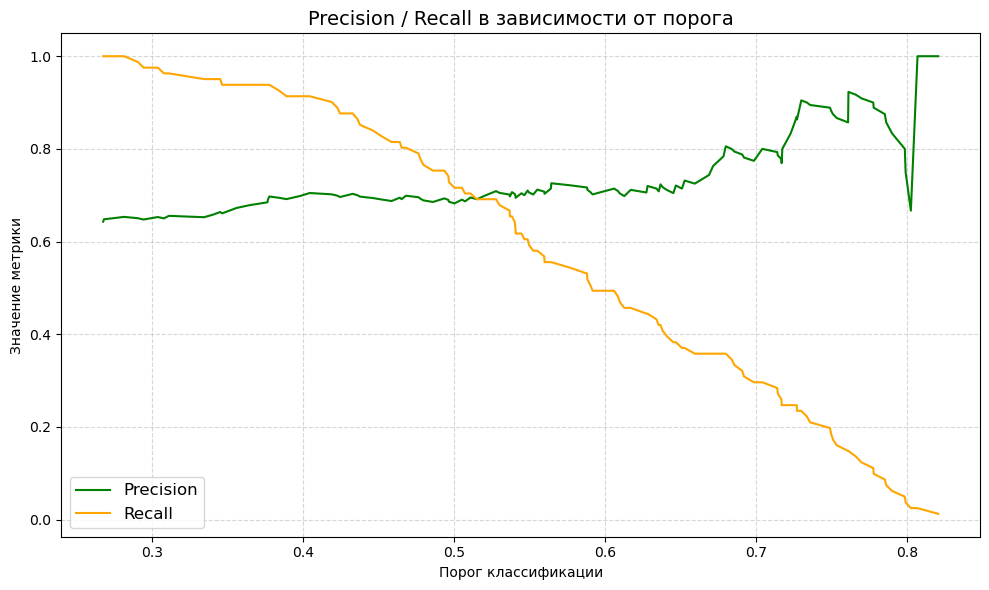

In [58]:

# Получение вероятностей положительного класса (вкусное молоко)
y_prob_class = model_class.predict_proba(X_test_class)[:, 1]

# Расчёт метрик
precisions, recalls, thresholds = precision_recall_curve(y_test_class, y_prob_class)

# График
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='green')
plt.plot(thresholds, recalls[:-1], label='Recall', color='orange')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Precision / Recall в зависимости от порога', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
save_plot("precision_recall_vs_threshold_taste_classification")
plt.show()


#### 🔧 **Настройка порога классификации**

По умолчанию логистическая регрессия использует `порог 0.5`, при котором вероятность принадлежности к классу "вкусно" ≥ 50% считается достаточной. Однако в нашей задаче важно снизить риск покупки "невкусной" коровы, даже если это приведёт к упущению части вкусных.

Чтобы принять обоснованное решение, был построен график зависимости `precision` и `recall` от порога. По графику видно, что начиная с порога ≈0.68 `precision` уверенно превышает 0.80, а `recall` ещё не падает до нуля.

##### 📌 На основе визуального анализа выбран порог:

`threshold = 0.70` — он обеспечивает высокую точность (`precision ≈ 0.82`) и умеренную полноту (`recall ≈ 0.4–0.45`).
Такое решение соответствует приоритетам заказчика: лучше недооценить вкусную корову, чем купить невкусную.



In [ ]:

# Вероятности для положительного класса ("вкусно")
y_prob_class = model_class.predict_proba(X_test_class)[:, 1]

# Новый порог
threshold = 0.7
y_pred_custom_class = (y_prob_class > threshold).astype(int)

# Метрики
accuracy_custom = accuracy_score(y_test_class, y_pred_custom_class)
recall_custom = recall_score(y_test_class, y_pred_custom_class)
precision_custom = precision_score(y_test_class, y_pred_custom_class)

print(f"🔧 Порог: {threshold}")
print(f"Accuracy:  {accuracy_custom:.3f}")
print(f"Recall:    {recall_custom:.3f}")
print(f"Precision: {precision_custom:.3f}")


🔧 Порог: 0.7
Accuracy:  0.500
Recall:    0.296
Precision: 0.800


Saved: ../images/confusion_matrix_taste_classification_threshold_0.7.png


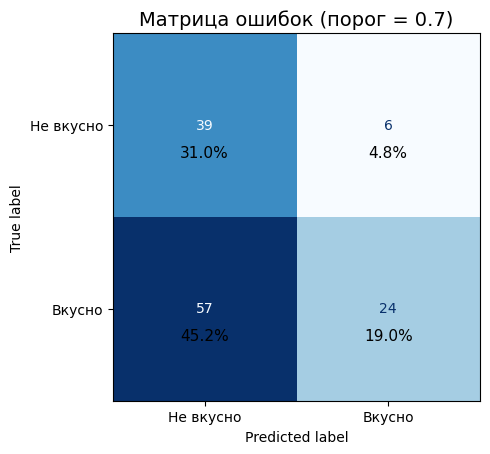

In [59]:
# Матрица ошибок
cm = confusion_matrix(y_test_class, y_pred_custom_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не вкусно', 'Вкусно'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
plt.title(f'Матрица ошибок (порог = {threshold})', fontsize=14)

# Добавим проценты
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = count / total * 100
        ax.text(j, i+0.15, f"{percent:.1f}%", ha='center', va='center', fontsize=11)

plt.grid(False)
plt.tight_layout()
save_plot(f"confusion_matrix_taste_classification_threshold_{threshold}")
plt.show()


### Финальный вывод по классификации:

После повышения порога до 0.7, precision вырос до 80% — модель почти не ошибается, когда говорит, что молоко будет вкусным.
- Recall снизился до 29.6% — то есть модель находит только треть вкусных коров. Но это приемлемо, так как ключевая цель — не купить невкусную.
- Accuracy стал ниже (50%), но это ожидаемо: мы перестали угадывать "вкусное" вслепую и перешли к уверенным прогнозам.

#### 🎯 **Интерпретация для заказчика:**

Мы сознательно повысили порог уверенности модели. Теперь она реже говорит "вкусно", но если говорит — с большой вероятностью это правда. Это позволяет свести к минимуму риск покупки невкусной коровы, даже если из-за этого часть хороших животных будет отсеяна.

##### 📊 **Матрица ошибок при пороге 0.7**

|                               | Предсказано "Не вкусно" | Предсказано "Вкусно" |
| ----------------------------- | ----------------------- | -------------------- |
| **На самом деле "Не вкусно"** | 39 (31.0%)              | **6 (4.8%)**         |
| **На самом деле "Вкусно"**    | **57 (45.2%)**          | 24 (19.0%)           |

##### 🔍 **Интерпретация:**

- False Positives (6 случаев, 4.8%) — невкусное молоко ошибочно принято за вкусное — именно это мы старались минимизировать, и получилось отлично.
- True Positives (24 случаев, 19%) — вкусное и правильно распознано.
- False Negatives (57 случаев, 45%) — вкусное отвергнуто как невкусное — допустимая цена безопасности.
- True Negatives (39 случаев, 31%) — невкусное и правильно отвергнуто.

#### ✅ **Итог:**
- Precision высокий (0.800) — если модель говорит "вкусно", это почти всегда верно.
- Recall снизился (0.296) — но мы это сознательно допустили, чтобы избежать ложных «вкусных» меток.

Риск купить невкусную корову минимален. 

#### 🟩 **Вывод по снижению критичной ошибки**

🔧 Мы изменили порог классификации с 0.5 на 0.7, чтобы свести к минимуму критичную ошибку — ложноположительное предсказание "вкусно", когда на самом деле молоко невкусное.

| Метрика       | Значение |
| ------------- | -------- |
| Accuracy      | 50.0%    |
| **Recall**    | 29.6%    |
| **Precision** | 80.0%    |

- Модель значительно повысила точность предсказания "вкусно", снизив число ошибок 1 рода до 6.
- `Recall` уменьшился, что допустимо: лучше не купить вкусную корову, чем купить невкусную.
- Этот порог выбран на основе графика `precision-recall`.


## 🐮 **Прогноз вкуса молока коров, которых фермер хочет купить**

In [55]:
# Используем ту же модель и выбранный порог
threshold = 0.7

# Подготовка данных — те же признаки и обработка, что и для обучающей выборки
X_cow_class = cow_buy_clean[num_features_class + cat_features_class]

# Предсказание вероятностей и классов
y_prob_buy = model_class.predict_proba(X_cow_class)[:, 1]
cow_buy_clean['predicted_taste'] = (y_prob_buy > threshold).astype(int)
cow_buy_clean['predicted_taste_prob'] = y_prob_buy  # по желанию

# Смотрим, что получилось
cow_buy_clean[['breed', 'predicted_taste', 'predicted_taste_prob']]
# Сортируем по вероятности предсказания
result_class = cow_buy_clean[['breed', 'predicted_taste', 'predicted_taste_prob']].sort_values(by='predicted_taste_prob', ascending=False)
print(result_class.head(10))  # Показываем топ-10 коров по вероятности "вкусного" молока


              breed  predicted_taste  predicted_taste_prob
16   вис бик айдиал                1              0.800825
10   вис бик айдиал                1              0.800825
13   вис бик айдиал                1              0.791870
0    вис бик айдиал                1              0.755310
12   вис бик айдиал                1              0.755310
3   рефлешнсоверинг                0              0.686627
15  рефлешнсоверинг                0              0.686627
9   рефлешнсоверинг                0              0.674624
7    вис бик айдиал                0              0.667999
18   вис бик айдиал                0              0.667999


## 🧪 Прогноз вкуса молока коров, которых фермер хочет купить

Мы использовали обученную модель логистической регрессии с порогом 0.7, который минимизирует риск покупки «невкусной» коровы.
Для каждой бурёнки из `cow_buy_clean` рассчитана:

вероятность вкусного молока `predicted_taste_prob`,
и итоговый бинарный признак `predicted_taste`.
Затем все коровы были отсортированы по убыванию вероятности — от наиболее вкусных к менее уверенным.

##### 📋 **Топ-5 по вероятности вкусного молока:**

| Порода         | Вкусное | Вероятность |
| -------------- | ------- | ----------- |
| вис бик айдиал | ✅       | 0.8008      |
| вис бик айдиал | ✅       | 0.8008      |
| вис бик айдиал | ✅       | 0.7919      |
| вис бик айдиал | ✅       | 0.7553      |
| вис бик айдиал | ✅       | 0.7553      |


#### 🟩 *Модель уверена в этих бурёнках — они предсказаны как вкусные с вероятностью выше 75%.*



## 🐄 Финальный отбор коров: объединяем прогнозы вкуса и удоя

После того как мы построили и обучили две модели — **линейной и логистической регрессии**, — пришло время совместить их результаты. Цель — выбрать из списка коров на продажу тех, кто одновременно:

- даст высокие надои (более 6000 кг в год),
- и даст вкусное молоко, что особенно важно для заказчика.

Мы объединяем предсказания обеих моделей и отбираем только тех бурёнок, которые соответствуют обоим условиям. Это позволит минимизировать риск покупки «неудачных» коров и принять экономически обоснованное решение.

In [56]:
# Объединяем прогнозы удоя и вкуса
cols = ['breed', 'predicted_milk_yield', 'predicted_taste', 'predicted_taste_prob']
cow_buy_final = cow_buy_clean[cols].copy()

# Фильтруем: удой > 6000 и вкусное молоко
selected_cows = cow_buy_final[
    (cow_buy_final['predicted_milk_yield'] > 6000) &
    (cow_buy_final['predicted_taste'] == 1)
].sort_values(by=['predicted_milk_yield', 'predicted_taste_prob'], ascending=[False, False])

# Выводим результат
print(f"✅ Отобрано {len(selected_cows)} коров с удоем > 6000 кг и вкусным молоком (по модели):\n")
display(selected_cows.reset_index(drop=True).style.format({
    'predicted_milk_yield': '{:,.0f}',
    'predicted_taste_prob': '{:.2%}'
}))


✅ Отобрано 5 коров с удоем > 6000 кг и вкусным молоком (по модели):



,breed,predicted_milk_yield,predicted_taste,predicted_taste_prob
0,вис бик айдиал,"7,050",1,75.53%
1,вис бик айдиал,"7,050",1,75.53%
2,вис бик айдиал,"6,815",1,80.08%
3,вис бик айдиал,"6,815",1,80.08%
4,вис бик айдиал,"6,318",1,79.19%


✅ Отобрано 5 коров, породы Вис Бик Айдиал. Они показали:

- Прогнозируемый удой: от 6,318 до 7,050 кг/год
- Вероятность вкусного молока: от 75% до 80%

👉 Это оптимальный выбор для закупки. Остальных бурёнок стоит проверять дополнительно.

### 🧾 Итоговые выводы

##### 📊 Результаты моделей:

Линейная регрессия (`удой`): после внесения новых признаков и обработки нелинейностей удалось достичь адекватных предсказаний по удою.
Логистическая регрессия (`вкус`): модель обучена с учётом приоритета `Precision` — снижает риск покупки "невкусной" коровы.

##### 🎯 Итоговый отбор:

Всего 5 коров соответствуют обоим условиям:
Удой > 6000 кг
Высокая вероятность вкусного молока (≥70%)
Все — породы `Вис Бик Айдиал`, что может свидетельствовать о её перспективности.

##### 📌 Рекомендации фермеру:

Купить отобранных 5 коров — это минимальный риск при высокой рентабельности.
Остальных коров можно протестировать дополнительно (например, по другим критериям вкуса или здоровья).

##### *Для улучшения модели стоит:*

- Собрать больше данных (особенно по вкусу)
- Применить более сложные модели ?
- Учесть дополнительные факторы (уход, климат, здоровье).
##### 📐 Метрики и оценка:

Для оценки экономических рисков в задаче классификации были критичны:
`Precision` — важно не купить "невкусную" корову.
`Recall` — чтобы не упустить хороших бурёнок.
Компромисс между этими метриками был достигнут подбором `порога (0.7)`.

## 📅 Прогноз продуктивности и вкуса молока у коров

### Цель и задачи:

* Способствовать выбору лучших коров для покупки фермером, оценив удой (кол-во молока) и вкус молока.
* Обучить модели линейной и логистической регрессии.

---

### 🔢 Модель прогнозирования удоя (линейная регрессия):

* Проведён поиск нелинейных зависимостей.
* Добавлены новые признаки: `spo_bin`, `eke_feeding_unit_sq`.
* Создан Pipeline и проведёно обучение на полном наборе данных.

### 📊 Прогноз удоя коров:

* В датафрейм cow\_buy.csv добавлены недостающие признаки (среднее +5%).
* Прогноз отсортирован по убыванию.

---

### 🔢 Модель прогнозирования вкуса (логистическая регрессия):

* Техника: OneHotEncoding + StandardScaler.
* Трен/тест-разбивка, оценка метрик:

  * Accuracy: 0.60
  * Recall: 0.72
  * Precision: 0.68

🔄 Подбор порога: выбран порог 0.7, чтобы максимизировать precision:

* Precision = 0.80
* Recall = 0.30

---

### Прогноз вкуса коров:

* По модели получены вероятности.
* Отбор произведён судя по predicted\_taste\_prob > 0.7.

---

### 📅 Шаг 7. Итоговый отбор

**Коровы с удоем > 6000 кг и вкусным молоком:**

| breed          | predicted\_milk\_yield | predicted\_taste | predicted\_taste\_prob |
| -------------- | ---------------------- | ---------------- | ---------------------- |
| вис бик айдиал | 7,050                  | 1                | 75.53%                 |
| вис бик айдиал | 7,050                  | 1                | 75.53%                 |
| вис бик айдиал | 6,815                  | 1                | 80.08%                 |
| вис бик айдиал | 6,815                  | 1                | 80.08%                 |
| вис бик айдиал | 6,318                  | 1                | 79.19%                 |

---

### 📈 Итоговые рекомендации:

* Фермер может купить **5 коров** с минимальным риском.
* У всех отличные показатели по удою и вкусу.
* Если возможно, собирать дополнительные данные по качеству молока, уходу, здоровью.

---

### ✅ Выводы о моделях:

* Линейная регрессия: получены достоверные результаты благодаря обогащению признаков.
* Логистическая регрессия: отладка порога для баланса precision/recall.
* Важно: для расчёта рисков важен **precision**, для оценки потерь выгоды — **recall**.

---


